Rows after US/ALL/ALL filter: 85
   Period_dt Geo Sector Name Sub-Sector Name
0 2019-01-01  US         ALL             ALL
1 2019-02-01  US         ALL             ALL
2 2019-03-01  US         ALL             ALL
3 2019-04-01  US         ALL             ALL
4 2019-05-01  US         ALL             ALL

Sanity check:
count    71.000000
mean      3.479591
std       1.853631
min       0.462461
25%       2.435541
50%       2.767266
75%       4.659169
max       7.243472
Name: pce_yoy, dtype: float64
count    70.000000
mean      0.013977
std       0.323517
min      -0.769531
25%      -0.118861
50%       0.034041
75%       0.166077
max       0.971279
Name: dpce_yoy, dtype: float64

Benchmark sample size: 69
FSBI sample size     : 69
Benchmark X shape: (69, 1)
FSBI X shape     : (69, 3)

=== OUT-OF-SAMPLE (Expanding Window) ===
OOS MSE Benchmark: 0.032160
OOS MSE FSBI     : 0.033699
OOS MSE reduction: -4.79%
OOS MAE Benchmark: 0.141430
OOS MAE FSBI     : 0.144268


/var/folders/q2/3fx178d13zjcqv_8h929ssxh0000gn/T/ipykernel_44874/1215366851.py:176: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds[t] = float(res.predict(X_te))


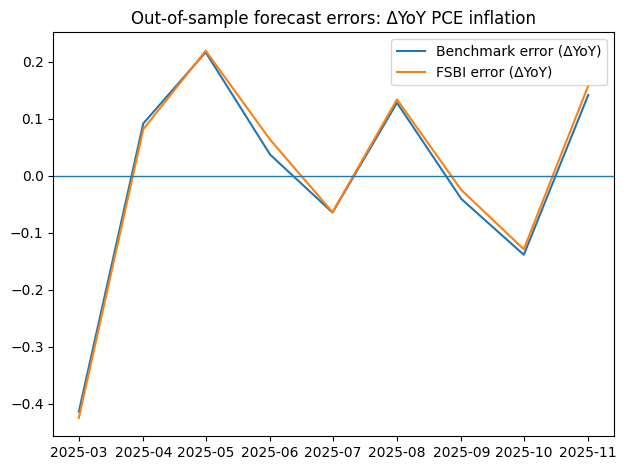

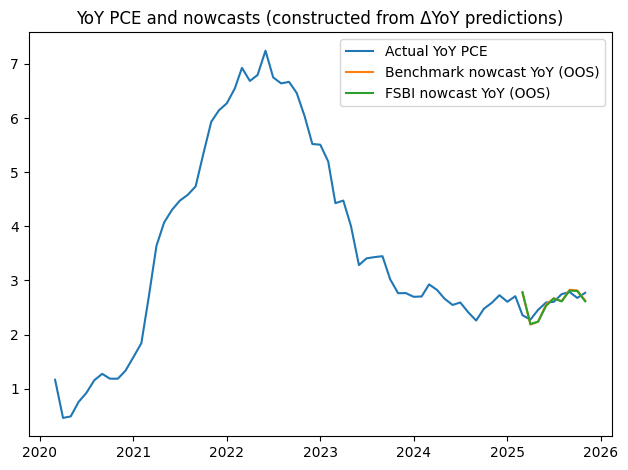


=== IN-SAMPLE: Benchmark (HAC) ===
               Coefficient  StdErr(HAC)  t(HAC)
const               0.0094       0.0325  0.2889
dpce_yoy_lag1       0.4934       0.1199  4.1150
In-sample MSE (Benchmark): 0.07899324095495315

=== IN-SAMPLE: FSBI-Augmented (HAC) ===
                Coefficient  StdErr(HAC)  t(HAC)
const                0.0114       0.0311  0.3670
fsbi_comp            0.0038       0.0007  5.0739
fsbi_comp_lag1       0.0014       0.0008  1.6646
dpce_yoy_lag1        0.4714       0.1210  3.8958
In-sample MSE (FSBI): 0.06704083918601073

bench_cols: ['dpce_yoy_lag1']
X_FSBI_COLS: ['fsbi_comp', 'fsbi_comp_lag1', 'dpce_yoy_lag1']


In [1]:
# ------------------------------------------------------------
# FSBI → Nowcast PCE (Richmond-style workflow) — CLEAN VERSION
# - Raw data (not normalized), no pre-made lags required
# - Filters to US/ALL/ALL (with fallbacks)
# - Computes YoY PCE inflation from PCE price index level
# - Target: ΔYoY PCE (change in YoY inflation)
# - Benchmark: ΔYoY ~ lags of ΔYoY
# - FSBI model: add FSBI signals (composite + lag1 by default) + inflation lags
# - Expanding-window OOS evaluation
# - HAC (Newey-West) in-sample tables
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =========================
# 0) PATH + COLUMN NAMES
# =========================
DATA_PATH = "../../data/fiserv_with_fred_appended.csv"

DATE_COL   = "Period_dt"
GEO_COL    = "Geo"
SECTOR_COL = "Sector Name"
SUB_COL    = "Sub-Sector Name"

# FSBI variables
SALES_IDX_COL = "Real Sales Index - SA"
TXN_IDX_COL   = "Transactional Index - SA"
SALES_MOM_COL = "Real Sales MOM % - SA"
TXN_MOM_COL   = "Transaction MOM % - SA"

# PCE price index LEVEL (must be the price index level)
PCE_LEVEL_COL = "PersonalConsumptionExpenditures"

# Settings
MAX_PI_LAG   = 2
MAX_FSBI_LAG = 2
MIN_TRAIN_N  = 60
HAC_LAGS     = 3

# =========================
# 1) LOAD + CLEAN
# =========================
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)

id_cols = {DATE_COL, "Period", "Month", GEO_COL, SECTOR_COL, SUB_COL}
for c in df.columns:
    if c not in id_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# =========================
# 2) FILTER TO US / ALL / ALL
# =========================
def filter_us_all_all(data: pd.DataFrame) -> pd.DataFrame:
    m1 = (data[GEO_COL].astype(str).str.upper() == "US") & \
         (data[SECTOR_COL].astype(str).str.upper() == "ALL") & \
         (data[SUB_COL].astype(str).str.upper() == "ALL")
    out = data.loc[m1].copy()
    if len(out) > 0:
        return out

    geo = data[GEO_COL].astype(str).str.upper()
    m2 = (geo.eq("UNITED STATES") | geo.str.contains("UNITED STATES", na=False)) & \
         (data[SECTOR_COL].astype(str).str.upper() == "ALL") & \
         (data[SUB_COL].astype(str).str.upper() == "ALL")
    out = data.loc[m2].copy()
    if len(out) > 0:
        return out

    # last resort: ALL/ALL regardless of Geo
    m3 = (data[SECTOR_COL].astype(str).str.upper() == "ALL") & \
         (data[SUB_COL].astype(str).str.upper() == "ALL")
    return data.loc[m3].copy()

monthly = filter_us_all_all(df).sort_values(DATE_COL).reset_index(drop=True)

print("Rows after US/ALL/ALL filter:", monthly.shape[0])
print(monthly[[DATE_COL, GEO_COL, SECTOR_COL, SUB_COL]].head())

# =========================
# 3) TARGET: YoY PCE inflation + ΔYoY
# =========================
monthly["pce_yoy"] = 100.0 * (monthly[PCE_LEVEL_COL] / monthly[PCE_LEVEL_COL].shift(12) - 1.0)
monthly["dpce_yoy"] = monthly["pce_yoy"] - monthly["pce_yoy"].shift(1)

for k in range(1, MAX_PI_LAG + 1):
    monthly[f"dpce_yoy_lag{k}"] = monthly["dpce_yoy"].shift(k)

print("\nSanity check:")
print(monthly["pce_yoy"].describe())
print(monthly["dpce_yoy"].describe())

# =========================
# 4) FSBI SIGNALS (EARLY INDICATORS)
# =========================
use_mom_cols = (SALES_MOM_COL in monthly.columns) and (TXN_MOM_COL in monthly.columns)

if use_mom_cols:
    monthly["fsbi_sales_signal"] = monthly[SALES_MOM_COL]
    monthly["fsbi_txn_signal"]   = monthly[TXN_MOM_COL]
else:
    monthly["fsbi_sales_signal"] = monthly[SALES_IDX_COL] - monthly[SALES_IDX_COL].shift(1)
    monthly["fsbi_txn_signal"]   = monthly[TXN_IDX_COL]   - monthly[TXN_IDX_COL].shift(1)

for k in range(1, MAX_FSBI_LAG + 1):
    monthly[f"fsbi_sales_signal_lag{k}"] = monthly["fsbi_sales_signal"].shift(k)
    monthly[f"fsbi_txn_signal_lag{k}"]   = monthly["fsbi_txn_signal"].shift(k)

# Composite (recommended for small samples)
monthly["fsbi_comp"] = (
    (monthly["fsbi_sales_signal"] - monthly["fsbi_sales_signal"].mean()) / monthly["fsbi_sales_signal"].std(ddof=0)
    + (monthly["fsbi_txn_signal"] - monthly["fsbi_txn_signal"].mean()) / monthly["fsbi_txn_signal"].std(ddof=0)
) * 12.0
for k in range(1, MAX_FSBI_LAG + 1):
    monthly[f"fsbi_comp_lag{k}"] = monthly["fsbi_comp"].shift(k)

# =========================
# 5) DEFINE REGRESSOR SETS (NO DUPLICATES)
# =========================
bench_cols = ["dpce_yoy_lag1"]


# FSBI spec options:
fsbi_cols_comp = ["fsbi_comp", "fsbi_comp_lag1"] + bench_cols
# Alternative: include up to lag2
# fsbi_cols_comp = ["fsbi_comp", "fsbi_comp_lag1", "fsbi_comp_lag2"] + bench_cols

# Alternative: two-series model (more parameters)
fsbi_cols_twoseries = [
    "fsbi_sales_signal", "fsbi_sales_signal_lag1", "fsbi_sales_signal_lag2",
    "fsbi_txn_signal",   "fsbi_txn_signal_lag1",   "fsbi_txn_signal_lag2",
] + bench_cols

X_FSBI_COLS = fsbi_cols_comp  # <-- start here

# Build separate model dataframes so we never double-include columns
df_b = monthly[[DATE_COL, "dpce_yoy"] + bench_cols].dropna().reset_index(drop=True)
df_f = monthly[[DATE_COL, "dpce_yoy"] + X_FSBI_COLS].dropna().reset_index(drop=True)

# Make sure dates align (they should, but this guarantees it)
common_dates = np.intersect1d(df_b[DATE_COL].values, df_f[DATE_COL].values)
df_b = df_b[df_b[DATE_COL].isin(common_dates)].sort_values(DATE_COL).reset_index(drop=True)
df_f = df_f[df_f[DATE_COL].isin(common_dates)].sort_values(DATE_COL).reset_index(drop=True)

assert np.all(df_b[DATE_COL].values == df_f[DATE_COL].values), "Date alignment failed!"

dates = df_b[DATE_COL].values
y = df_b["dpce_yoy"].values

X_bench = df_b[bench_cols].to_numpy()
X_fsbi  = df_f[X_FSBI_COLS].to_numpy()

print("\nBenchmark sample size:", len(df_b))
print("FSBI sample size     :", len(df_f))
print("Benchmark X shape:", X_bench.shape)
print("FSBI X shape     :", X_fsbi.shape)

# =========================
# 6) EXPANDING-WINDOW OUT-OF-SAMPLE FORECAST
# =========================
def expanding_oos_forecast(y_vec, X_mat, min_train_n=60):
    T = len(y_vec)
    preds = np.full(T, np.nan)
    for t in range(min_train_n, T):
        y_tr = y_vec[:t]
        X_tr = sm.add_constant(X_mat[:t, :], has_constant="add")
        X_te = sm.add_constant(X_mat[t:t+1, :], has_constant="add")
        res = sm.OLS(y_tr, X_tr).fit()
        preds[t] = float(res.predict(X_te))
    return preds

pred_b = expanding_oos_forecast(y, X_bench, min_train_n=MIN_TRAIN_N)
pred_f = expanding_oos_forecast(y, X_fsbi,  min_train_n=MIN_TRAIN_N)

mask = ~np.isnan(pred_b) & ~np.isnan(pred_f)
y_oos = y[mask]
pb = pred_b[mask]
pf = pred_f[mask]
dates_oos = dates[mask]

mse_b = mean_squared_error(y_oos, pb)
mse_f = mean_squared_error(y_oos, pf)
mae_b = mean_absolute_error(y_oos, pb)
mae_f = mean_absolute_error(y_oos, pf)

print("\n=== OUT-OF-SAMPLE (Expanding Window) ===")
print(f"OOS MSE Benchmark: {mse_b:.6f}")
print(f"OOS MSE FSBI     : {mse_f:.6f}")
print(f"OOS MSE reduction: {(1 - mse_f/mse_b)*100:.2f}%")
print(f"OOS MAE Benchmark: {mae_b:.6f}")
print(f"OOS MAE FSBI     : {mae_f:.6f}")

# =========================
# 7) PLOTS: ERROR + NOWCAST YoY LEVEL
# =========================
err_b = y_oos - pb
err_f = y_oos - pf

plt.figure()
plt.plot(dates_oos, err_b, label="Benchmark error (ΔYoY)")
plt.plot(dates_oos, err_f, label="FSBI error (ΔYoY)")
plt.axhline(0, linewidth=1)
plt.title("Out-of-sample forecast errors: ΔYoY PCE inflation")
plt.legend()
plt.tight_layout()
plt.show()

# Nowcast YoY level: π̂_t = π_{t-1} + Δπ̂_t
pce_yoy_aligned = monthly.set_index(DATE_COL).loc[pd.to_datetime(dates), "pce_yoy"].values

pce_hat_b = np.full_like(pce_yoy_aligned, np.nan, dtype=float)
pce_hat_f = np.full_like(pce_yoy_aligned, np.nan, dtype=float)

for i in range(1, len(dates)):
    if mask[i]:
        pce_hat_b[i] = pce_yoy_aligned[i-1] + pred_b[i]
        pce_hat_f[i] = pce_yoy_aligned[i-1] + pred_f[i]

plt.figure()
plt.plot(dates, pce_yoy_aligned, label="Actual YoY PCE")
plt.plot(dates, pce_hat_b, label="Benchmark nowcast YoY (OOS)")
plt.plot(dates, pce_hat_f, label="FSBI nowcast YoY (OOS)")
plt.title("YoY PCE and nowcasts (constructed from ΔYoY predictions)")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 8) IN-SAMPLE TABLES WITH HAC (LIKE PAPER)
# =========================
def fit_hac(y_series, X_df, hac_lags=3):
    Xc = sm.add_constant(X_df, has_constant="add")
    res = sm.OLS(y_series, Xc).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    tab = pd.DataFrame(
        {"Coefficient": res.params, "StdErr(HAC)": res.bse, "t(HAC)": res.tvalues},
        index=Xc.columns
    )
    return res, tab

res_b, tab_b = fit_hac(df_b["dpce_yoy"], df_b[bench_cols], hac_lags=HAC_LAGS)
res_f, tab_f = fit_hac(df_f["dpce_yoy"], df_f[X_FSBI_COLS], hac_lags=HAC_LAGS)

print("\n=== IN-SAMPLE: Benchmark (HAC) ===")
print(tab_b.round(4))
print("In-sample MSE (Benchmark):", mean_squared_error(df_b["dpce_yoy"], res_b.fittedvalues))

print("\n=== IN-SAMPLE: FSBI-Augmented (HAC) ===")
print(tab_f.round(4))
print("In-sample MSE (FSBI):", mean_squared_error(df_f["dpce_yoy"], res_f.fittedvalues))

print("\nbench_cols:", bench_cols)
print("X_FSBI_COLS:", X_FSBI_COLS)

In [2]:
# ============================================================
# METRIC HELPERS: Directional Accuracy + MAPE
# ============================================================
def directional_accuracy(y_true, y_pred):
    """
    % of periods where the model correctly predicts whether
    y_true moves UP or DOWN relative to the previous period.
    
    i.e., sign(y_true[t] - y_true[t-1]) == sign(y_pred[t] - y_pred[t-1])
    """
    import numpy as np
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    actual_dir    = np.sign(np.diff(y_true))
    predicted_dir = np.sign(np.diff(y_pred))
    
    # Exclude ties (where diff == 0)
    mask = actual_dir != 0
    if mask.sum() == 0:
        return np.nan
    
    return (actual_dir[mask] == predicted_dir[mask]).mean() * 100.0

def mape(y_true, y_pred, eps=1e-6):
    """
    Mean Absolute Percentage Error (%).
    Uses a small epsilon to avoid division by zero.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100.0

Sanity check pce_yoy:
count    71.000000
mean      3.479591
std       1.853631
min       0.462461
25%       2.435541
50%       2.767266
75%       4.659169
max       7.243472
Name: pce_yoy, dtype: float64

Sample size: 70
Benchmark X shape: (70, 1)
FSBI X shape     : (70, 2)

=== OUT-OF-SAMPLE (YoY level) ===
OOS MSE Benchmark: 0.023533
OOS MSE FSBI     : 0.021788
OOS MSE reduction: 7.42%
OOS MAE Benchmark: 0.116575
OOS MAE FSBI     : 0.115734

*** OOS Directional Accuracy Benchmark: 55.6%
*** OOS Directional Accuracy FSBI     : 55.6%
*** OOS MAPE Benchmark: 4.66%
*** OOS MAPE FSBI     : 4.63%


/var/folders/q2/3fx178d13zjcqv_8h929ssxh0000gn/T/ipykernel_44874/2954613259.py:112: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds[t] = float(res.predict(X_te))


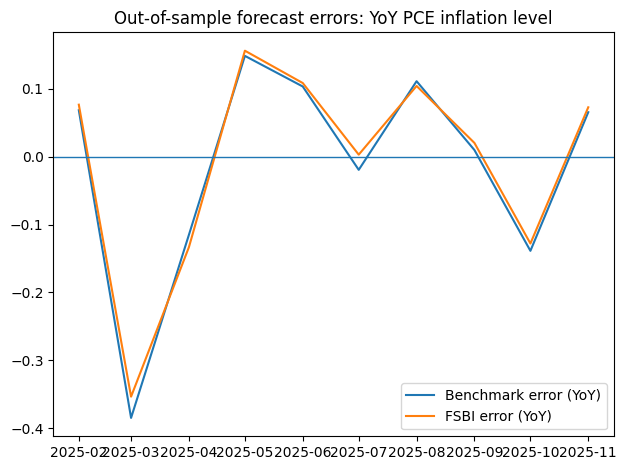

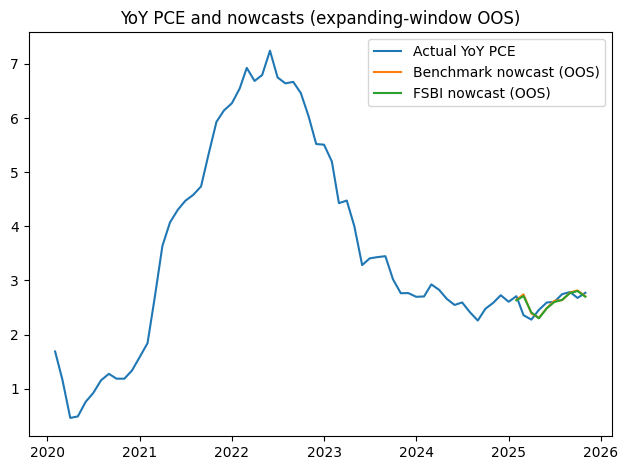


=== IN-SAMPLE (YoY level): Benchmark HAC ===
              Coefficient  StdErr(HAC)   t(HAC)
const              0.0837       0.1017   0.8230
pce_yoy_lag1       0.9800       0.0271  36.2157

=== IN-SAMPLE (YoY level): FSBI HAC ===
                Coefficient  StdErr(HAC)   t(HAC)
const                0.0789       0.0937   0.8417
fsbi_comp_lag1       0.0036       0.0011   3.3498
pce_yoy_lag1         0.9816       0.0263  37.3267

BENCH_COLS: ['pce_yoy_lag1']
FSBI_COLS : ['fsbi_comp_lag1', 'pce_yoy_lag1']


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -------------------------
# Assumes you already have:
# monthly dataframe (US/ALL/ALL), sorted by DATE_COL
# and these columns exist:
#   - PCE_LEVEL_COL (PCE price index level)
#   - fsbi_sales_signal, fsbi_txn_signal OR the MoM% cols
# If not, set these and run the construction blocks below.
# -------------------------

DATE_COL = "Period_dt"
PCE_LEVEL_COL = "PersonalConsumptionExpenditures"

# FSBI inputs (same as before)
SALES_MOM_COL = "Real Sales MOM % - SA"
TXN_MOM_COL   = "Transaction MOM % - SA"
SALES_IDX_COL = "Real Sales Index - SA"
TXN_IDX_COL   = "Transactional Index - SA"

MIN_TRAIN_N = 60
HAC_LAGS = 3

# ================
# 1) Target: YoY level π_t
# ================
monthly = monthly.copy()
monthly = monthly.sort_values(DATE_COL).reset_index(drop=True)

monthly["pce_yoy"] = 100.0 * (monthly[PCE_LEVEL_COL] / monthly[PCE_LEVEL_COL].shift(12) - 1.0)

# lag(s) of YoY level
monthly["pce_yoy_lag1"] = monthly["pce_yoy"].shift(1)
monthly["pce_yoy_lag2"] = monthly["pce_yoy"].shift(2)

print("Sanity check pce_yoy:")
print(monthly["pce_yoy"].describe())

# ================
# 2) FSBI signal + composite (rebuild safely here)
# ================
use_mom_cols = (SALES_MOM_COL in monthly.columns) and (TXN_MOM_COL in monthly.columns)

if use_mom_cols:
    monthly["fsbi_sales_signal"] = monthly[SALES_MOM_COL]
    monthly["fsbi_txn_signal"]   = monthly[TXN_MOM_COL]
else:
    monthly["fsbi_sales_signal"] = monthly[SALES_IDX_COL] - monthly[SALES_IDX_COL].shift(1)
    monthly["fsbi_txn_signal"]   = monthly[TXN_IDX_COL]   - monthly[TXN_IDX_COL].shift(1)

# Composite (standardize)
monthly["fsbi_comp"] = (
    (monthly["fsbi_sales_signal"] - monthly["fsbi_sales_signal"].mean()) / monthly["fsbi_sales_signal"].std(ddof=0)
    + (monthly["fsbi_txn_signal"] - monthly["fsbi_txn_signal"].mean()) / monthly["fsbi_txn_signal"].std(ddof=0)
) * 12.0
monthly["fsbi_comp_lag1"] = monthly["fsbi_comp"].shift(1)

# ================
# 3) Define models
# ================
# Benchmarks: AR(1) and AR(2) on YoY level
bench1_cols = ["pce_yoy_lag1"]
bench2_cols = ["pce_yoy_lag1", "pce_yoy_lag2"]

# FSBI models (keep parsimonious)
# Start with FSBI + AR(1)
fsbi1_cols = ["fsbi_comp", "pce_yoy_lag1"]

# Optional: FSBI + FSBI lag + AR(1)
fsbi2_cols = ["fsbi_comp", "fsbi_comp_lag1", "pce_yoy_lag1"]

# Pick which benchmark & fsbi spec you want to compare first:
BENCH_COLS = bench1_cols
FSBI_COLS = ["fsbi_comp_lag1", "pce_yoy_lag1"]

# ================
# 4) Build aligned datasets (no duplicates; same dates)
# ================
df_b = monthly[[DATE_COL, "pce_yoy"] + BENCH_COLS].dropna().reset_index(drop=True)
df_f = monthly[[DATE_COL, "pce_yoy"] + FSBI_COLS].dropna().reset_index(drop=True)

common_dates = np.intersect1d(df_b[DATE_COL].values, df_f[DATE_COL].values)
df_b = df_b[df_b[DATE_COL].isin(common_dates)].sort_values(DATE_COL).reset_index(drop=True)
df_f = df_f[df_f[DATE_COL].isin(common_dates)].sort_values(DATE_COL).reset_index(drop=True)
assert np.all(df_b[DATE_COL].values == df_f[DATE_COL].values)

dates = df_b[DATE_COL].values
y = df_b["pce_yoy"].values

X_bench = df_b[BENCH_COLS].to_numpy()
X_fsbi  = df_f[FSBI_COLS].to_numpy()

print("\nSample size:", len(y))
print("Benchmark X shape:", X_bench.shape)
print("FSBI X shape     :", X_fsbi.shape)

# ================
# 5) Expanding-window OOS forecasts
# ================
def expanding_oos_forecast(y_vec, X_mat, min_train_n=60):
    T = len(y_vec)
    preds = np.full(T, np.nan)
    for t in range(min_train_n, T):
        y_tr = y_vec[:t]
        X_tr = sm.add_constant(X_mat[:t, :], has_constant="add")
        X_te = sm.add_constant(X_mat[t:t+1, :], has_constant="add")
        res = sm.OLS(y_tr, X_tr).fit()
        preds[t] = float(res.predict(X_te))
    return preds

pred_b = expanding_oos_forecast(y, X_bench, min_train_n=MIN_TRAIN_N)
pred_f = expanding_oos_forecast(y, X_fsbi,  min_train_n=MIN_TRAIN_N)

mask = ~np.isnan(pred_b) & ~np.isnan(pred_f)
y_oos = y[mask]
pb = pred_b[mask]
pf = pred_f[mask]
dates_oos = dates[mask]

mse_b = mean_squared_error(y_oos, pb)
mse_f = mean_squared_error(y_oos, pf)
mae_b = mean_absolute_error(y_oos, pb)
mae_f = mean_absolute_error(y_oos, pf)

print("\n=== OUT-OF-SAMPLE (YoY level) ===")
print(f"OOS MSE Benchmark: {mse_b:.6f}")
print(f"OOS MSE FSBI     : {mse_f:.6f}")
print(f"OOS MSE reduction: {(1 - mse_f/mse_b)*100:.2f}%")
print(f"OOS MAE Benchmark: {mae_b:.6f}")
print(f"OOS MAE FSBI     : {mae_f:.6f}")

da_b = directional_accuracy(y_oos, pb)
da_f = directional_accuracy(y_oos, pf)
mape_b = mape(y_oos, pb)
mape_f = mape(y_oos, pf)

print()
print(f"*** OOS Directional Accuracy Benchmark: {da_b:.1f}%")
print(f"*** OOS Directional Accuracy FSBI     : {da_f:.1f}%")
print(f"*** OOS MAPE Benchmark: {mape_b:.2f}%")
print(f"*** OOS MAPE FSBI     : {mape_f:.2f}%")

# ================
# 6) Plots
# ================
# Errors
plt.figure()
plt.plot(dates_oos, y_oos - pb, label="Benchmark error (YoY)")
plt.plot(dates_oos, y_oos - pf, label="FSBI error (YoY)")
plt.axhline(0, linewidth=1)
plt.title("Out-of-sample forecast errors: YoY PCE inflation level")
plt.legend()
plt.tight_layout()
plt.show()

# Actual vs predicted YoY
plt.figure()
plt.plot(dates, y, label="Actual YoY PCE")
plt.plot(dates, pred_b, label="Benchmark nowcast (OOS)")
plt.plot(dates, pred_f, label="FSBI nowcast (OOS)")
plt.title("YoY PCE and nowcasts (expanding-window OOS)")
plt.legend()
plt.tight_layout()
plt.show()

# ================
# 7) HAC in-sample tables (like the paper)
# ================
def fit_hac(y_series, X_df, hac_lags=3):
    Xc = sm.add_constant(X_df, has_constant="add")
    res = sm.OLS(y_series, Xc).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    tab = pd.DataFrame(
        {"Coefficient": res.params, "StdErr(HAC)": res.bse, "t(HAC)": res.tvalues},
        index=Xc.columns
    )
    return res, tab

res_b, tab_b = fit_hac(df_b["pce_yoy"], df_b[BENCH_COLS], hac_lags=HAC_LAGS)
res_f, tab_f = fit_hac(df_f["pce_yoy"], df_f[FSBI_COLS], hac_lags=HAC_LAGS)

print("\n=== IN-SAMPLE (YoY level): Benchmark HAC ===")
print(tab_b.round(4))

print("\n=== IN-SAMPLE (YoY level): FSBI HAC ===")
print(tab_f.round(4))

print("\nBENCH_COLS:", BENCH_COLS)
print("FSBI_COLS :", FSBI_COLS)

In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# =========================
# ASSUMES you already have:
#   monthly dataframe filtered to US/ALL/ALL
#   monthly[DATE_COL] as datetime
#   monthly[PCE_LEVEL_COL] as the PCE *price index level*
#   monthly["fsbi_comp"] already built (or we rebuild it here)
# =========================

DATE_COL = "Period_dt"
PCE_LEVEL_COL = "PersonalConsumptionExpenditures"

# FSBI columns (used to build fsbi_comp if needed)
SALES_MOM_COL = "Real Sales MOM % - SA"
TXN_MOM_COL   = "Transaction MOM % - SA"
SALES_IDX_COL = "Real Sales Index - SA"
TXN_IDX_COL   = "Transactional Index - SA"

# 1) Ensure sorted
monthly = monthly.copy().sort_values(DATE_COL).reset_index(drop=True)

# 2) Build YoY PCE inflation level π_t from the PCE price index level
#    π_t = 100 * (P_t / P_{t-12} - 1)
monthly["pce_yoy"] = 100.0 * (monthly[PCE_LEVEL_COL] / monthly[PCE_LEVEL_COL].shift(12) - 1.0)
monthly["pce_yoy_lag1"] = monthly["pce_yoy"].shift(1)

# 3) Build FSBI composite and its lag (if not already in df)
if "fsbi_comp" not in monthly.columns:
    use_mom_cols = (SALES_MOM_COL in monthly.columns) and (TXN_MOM_COL in monthly.columns)
    if use_mom_cols:
        monthly["fsbi_sales_signal"] = monthly[SALES_MOM_COL]
        monthly["fsbi_txn_signal"]   = monthly[TXN_MOM_COL]
    else:
        monthly["fsbi_sales_signal"] = monthly[SALES_IDX_COL] - monthly[SALES_IDX_COL].shift(1)
        monthly["fsbi_txn_signal"]   = monthly[TXN_IDX_COL]   - monthly[TXN_IDX_COL].shift(1)

    monthly["fsbi_comp"] = (
        (monthly["fsbi_sales_signal"] - monthly["fsbi_sales_signal"].mean()) / monthly["fsbi_sales_signal"].std(ddof=0)
        + (monthly["fsbi_txn_signal"] - monthly["fsbi_txn_signal"].mean()) / monthly["fsbi_txn_signal"].std(ddof=0)
    ) * 12.0

monthly["fsbi_comp_lag1"] = monthly["fsbi_comp"].shift(1)

# 4) Model dataset for:  pce_yoy_t ~ fsbi_comp_{t-1} + pce_yoy_{t-1}
model_cols = ["pce_yoy", "pce_yoy_lag1", "fsbi_comp_lag1"]
mdf = monthly[[DATE_COL, PCE_LEVEL_COL] + model_cols].dropna().reset_index(drop=True)

# 5) Fit model on ALL available data (this is what you'd do "today")
y = mdf["pce_yoy"]
X = sm.add_constant(mdf[["fsbi_comp_lag1", "pce_yoy_lag1"]], has_constant="add")
res = sm.OLS(y, X).fit()

print(res.summary())

# 6) NOWCAST for the most recent month in mdf (last row)
#    This corresponds to predicting π_t using info available by t (FSBI_{t-1}, π_{t-1})
last_row = mdf.iloc[-1]
X_now = sm.add_constant(
    pd.DataFrame([{
        "fsbi_comp_lag1": last_row["fsbi_comp_lag1"],
        "pce_yoy_lag1":   last_row["pce_yoy_lag1"]
    }]),
    has_constant="add"
)
pce_yoy_nowcast = float(res.predict(X_now).iloc[0])

print("\n=== NOWCAST (YoY PCE inflation) ===")
print("Month:", last_row[DATE_COL].date())
print("Nowcast YoY PCE inflation (%):", round(pce_yoy_nowcast, 3))
print("Last month actual YoY PCE (%):", round(float(last_row["pce_yoy_lag1"]), 3))

# 7) OPTIONAL: Convert predicted YoY inflation into an implied PCE price index LEVEL forecast
#    If YoY inflation is π_t, then P_t_hat = (1 + π_t/100) * P_{t-12}
#    This gives a forecast of the *index level* for month t.
P_t_12 = float(mdf.loc[mdf.index[-1], PCE_LEVEL_COL])  # careful: this is P_t, not P_{t-12}

# We need P_{t-12} for the last date:
t = last_row[DATE_COL]
P_t_12m_ago = float(monthly.set_index(DATE_COL).loc[t - pd.DateOffset(months=12), PCE_LEVEL_COL])

pce_level_hat = (1.0 + pce_yoy_nowcast/100.0) * P_t_12m_ago

print("\n=== IMPLIED PCE PRICE INDEX LEVEL FORECAST ===")
print("Month:", t.date())
print("Forecast PCE price index level:", round(pce_level_hat, 3))
print("Actual PCE price index level (if already known in your file):", round(float(last_row[PCE_LEVEL_COL]), 3))


# 8) Helper: nowcast for a specific month (YYYY-MM-01)
def nowcast_pce_yoy_for_month(target_month: str) -> float:
    """
    target_month like '2025-12-01' (must exist in monthly[DATE_COL]).
    Uses model estimated on data up to target_month-1 (expanding-window real-time).
    """
    target_dt = pd.to_datetime(target_month)

    # Build the needed rows
    # We need pce_yoy_{t-1} and fsbi_comp_{t-1} to predict pce_yoy_t
    # Fit using data strictly before target_dt (real-time style)
    train = mdf[mdf[DATE_COL] < target_dt].copy()
    if len(train) < 24:
        raise ValueError("Not enough training data before target month.")

    y_tr = train["pce_yoy"]
    X_tr = sm.add_constant(train[["fsbi_comp_lag1", "pce_yoy_lag1"]], has_constant="add")
    res_tr = sm.OLS(y_tr, X_tr).fit()

    test_row = mdf[mdf[DATE_COL] == target_dt]
    if test_row.empty:
        raise ValueError("Target month not available in mdf (check dates / required lags).")
    test_row = test_row.iloc[0]

    X_te = sm.add_constant(pd.DataFrame([{
        "fsbi_comp_lag1": test_row["fsbi_comp_lag1"],
        "pce_yoy_lag1":   test_row["pce_yoy_lag1"]
    }]), has_constant="add")

    return float(res_tr.predict(X_te).iloc[0])

# Example usage:
# print(nowcast_pce_yoy_for_month("2025-12-01"))

                            OLS Regression Results                            
Dep. Variable:                pce_yoy   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     1189.
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           4.59e-53
Time:                        20:53:06   Log-Likelihood:                -16.194
No. Observations:                  70   AIC:                             38.39
Df Residuals:                      67   BIC:                             45.13
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0789      0.080      0.

/var/folders/q2/3fx178d13zjcqv_8h929ssxh0000gn/T/ipykernel_44874/112443234.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds[t] = float(res.predict(X_te))


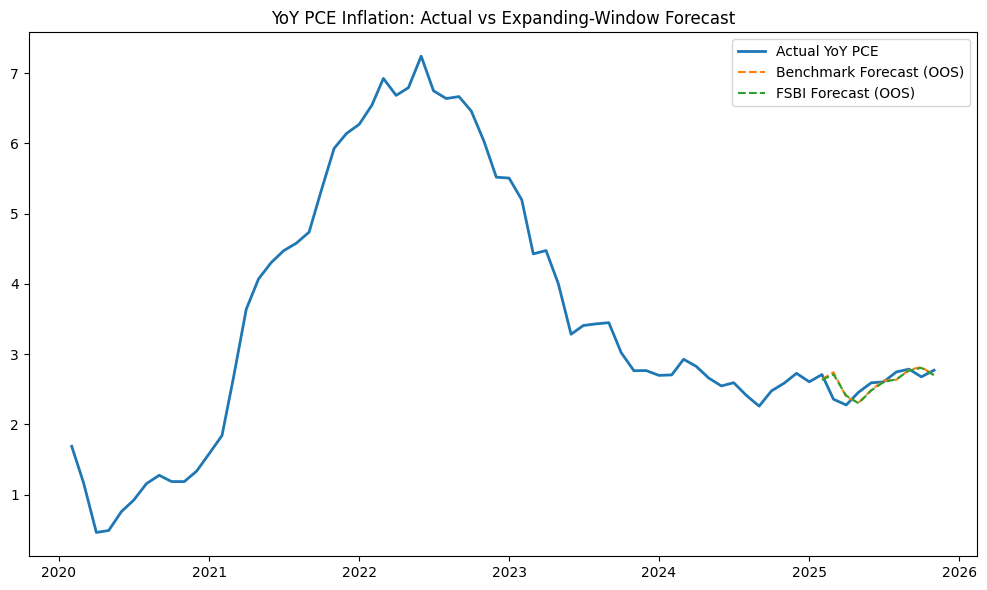

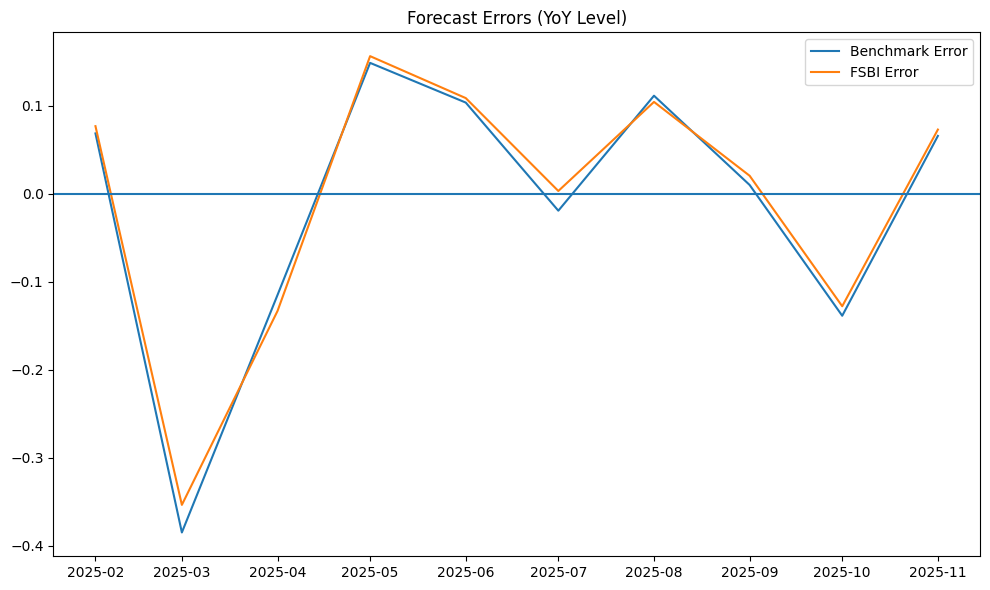

         Date  Actual_YoY_PCE  Benchmark_Forecast  FSBI_Forecast
55 2024-09-01        2.260766                 NaN            NaN
56 2024-10-01        2.477693                 NaN            NaN
57 2024-11-01        2.587803                 NaN            NaN
58 2024-12-01        2.728095                 NaN            NaN
59 2025-01-01        2.607380                 NaN            NaN
60 2025-02-01        2.710485            2.641903       2.633673
61 2025-03-01        2.359434            2.744315       2.712967
62 2025-04-01        2.277426            2.392424       2.410625
63 2025-05-01        2.458086            2.309363       2.301715
64 2025-06-01        2.593513            2.489912       2.484800
65 2025-07-01        2.605547            2.624776       2.602396
66 2025-08-01        2.747621            2.636209       2.643249
67 2025-09-01        2.787442            2.777477       2.767004
68 2025-10-01        2.678041            2.816666       2.805851
69 2025-11-01        2.77

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# =========================================
# 1) Rebuild model dataset (YoY level spec)
# =========================================

DATE_COL = "Period_dt"

monthly = monthly.sort_values(DATE_COL).reset_index(drop=True)

# Ensure target and regressors exist
monthly["pce_yoy"] = 100.0 * (monthly[PCE_LEVEL_COL] / monthly[PCE_LEVEL_COL].shift(12) - 1.0)
monthly["pce_yoy_lag1"] = monthly["pce_yoy"].shift(1)
monthly["fsbi_comp_lag1"] = monthly["fsbi_comp"].shift(1)

model_cols = ["pce_yoy", "pce_yoy_lag1", "fsbi_comp_lag1"]
df_model = monthly[[DATE_COL] + model_cols].dropna().reset_index(drop=True)

dates = df_model[DATE_COL].values
y = df_model["pce_yoy"].values
X_bench = df_model[["pce_yoy_lag1"]].to_numpy()
X_fsbi  = df_model[["fsbi_comp_lag1", "pce_yoy_lag1"]].to_numpy()

# =========================================
# 2) Expanding-window forecasts
# =========================================

MIN_TRAIN_N = 60

def expanding_oos_forecast(y_vec, X_mat, min_train_n=60):
    T = len(y_vec)
    preds = np.full(T, np.nan)
    for t in range(min_train_n, T):
        y_tr = y_vec[:t]
        X_tr = sm.add_constant(X_mat[:t, :], has_constant="add")
        X_te = sm.add_constant(X_mat[t:t+1, :], has_constant="add")
        res = sm.OLS(y_tr, X_tr).fit()
        preds[t] = float(res.predict(X_te))
    return preds

pred_bench = expanding_oos_forecast(y, X_bench, MIN_TRAIN_N)
pred_fsbi  = expanding_oos_forecast(y, X_fsbi,  MIN_TRAIN_N)

# =========================================
# 3) Plot Actual vs Forecast
# =========================================

plt.figure(figsize=(10,6))
plt.plot(dates, y, label="Actual YoY PCE", linewidth=2)
plt.plot(dates, pred_bench, label="Benchmark Forecast (OOS)", linestyle="--")
plt.plot(dates, pred_fsbi, label="FSBI Forecast (OOS)", linestyle="--")
plt.title("YoY PCE Inflation: Actual vs Expanding-Window Forecast")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================
# 4) Forecast Errors Plot
# =========================================

mask = ~np.isnan(pred_bench)
plt.figure(figsize=(10,6))
plt.plot(dates[mask], y[mask] - pred_bench[mask], label="Benchmark Error")
plt.plot(dates[mask], y[mask] - pred_fsbi[mask], label="FSBI Error")
plt.axhline(0)
plt.title("Forecast Errors (YoY Level)")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================
# 5) Create comparison table for CSV check
# =========================================

results_df = pd.DataFrame({
    "Date": dates,
    "Actual_YoY_PCE": y,
    "Benchmark_Forecast": pred_bench,
    "FSBI_Forecast": pred_fsbi,
})

print(results_df.tail(15))

In [6]:
import pandas as pd
import statsmodels.api as sm

DATE_COL = "Period_dt"
TRAIN_END_DATE = pd.to_datetime("2025-09-01")

# -------------------------------------------------
# 1. Train the model using data through September 2025
# -------------------------------------------------
train_cols = ["pce_yoy", "pce_yoy_lag1", "fsbi_comp_lag1"]
train_df = monthly[[DATE_COL] + train_cols].dropna().reset_index(drop=True)
train_df = train_df.loc[train_df[DATE_COL] <= TRAIN_END_DATE].copy()

X_train = train_df[["fsbi_comp_lag1", "pce_yoy_lag1"]].copy()
X_train = sm.add_constant(X_train, has_constant="add")
y_train = train_df["pce_yoy"]

model = sm.OLS(y_train, X_train).fit()

print(f"Training sample ends at: {train_df[DATE_COL].max().date()}")
print(f"Number of training rows: {len(train_df)}")
print(model.summary())

# -------------------------------------------------
# 2. Forecast function
# -------------------------------------------------
def forecast_month(target_date, df, model):
    row = df.loc[df[DATE_COL] == target_date]
    if row.empty:
        raise ValueError(f"Date {target_date} not found in dataset.")

    row = row.iloc[0]

    X_new = pd.DataFrame({
        "const": [1.0],
        "fsbi_comp_lag1": [row["fsbi_comp_lag1"]],
        "pce_yoy_lag1": [row["pce_yoy_lag1"]],
    })

    # Force same column order as training model
    X_new = X_new[model.model.exog_names]

    pred = float(model.predict(X_new).iloc[0])
    return pred

# -------------------------------------------------
# 3. Forecast post-training months
# -------------------------------------------------
from sklearn.metrics import mean_squared_error
import numpy as np

months_to_forecast = ["2025-10-01", "2025-11-01", "2025-12-01"]

results = []
for m in months_to_forecast:
    dt = pd.to_datetime(m)
    pred = forecast_month(dt, monthly, model)

    actual_series = monthly.loc[monthly[DATE_COL] == dt, "pce_yoy"]
    actual_val = float(actual_series.iloc[0]) if not actual_series.empty else None

    results.append({
        "Month": m,
        "Predicted_YoY_PCE": pred,
        "Actual_YoY_PCE": actual_val
    })

results_df = pd.DataFrame(results)
print(results_df)

# RMSE on test set
eval_df = results_df.dropna(subset=["Actual_YoY_PCE"]).copy()
rmse = np.sqrt(mean_squared_error(eval_df["Actual_YoY_PCE"], eval_df["Predicted_YoY_PCE"]))
print(f"Test RMSE for yoy change: {rmse:.4f}")

Training sample ends at: 2025-09-01
Number of training rows: 68
                            OLS Regression Results                            
Dep. Variable:                pce_yoy   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     1152.
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.79e-51
Time:                        20:53:06   Log-Likelihood:                -16.606
No. Observations:                  68   AIC:                             39.21
Df Residuals:                      65   BIC:                             45.87
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

In [7]:
import pandas as pd

results = []

for m in months_to_forecast:

    dt = pd.to_datetime(m)

    # Forecast YoY inflation
    pred_yoy = forecast_month(dt, monthly, model)

    # Actual YoY if available
    actual_yoy = monthly.loc[monthly[DATE_COL] == dt, "pce_yoy"]
    actual_yoy_val = float(actual_yoy.iloc[0]) if not actual_yoy.empty else None

    # Get PCE index level from 12 months earlier
    lag12_date = dt - pd.DateOffset(months=12)

    pce_lag12 = monthly.loc[monthly[DATE_COL] == lag12_date, PCE_LEVEL_COL]

    if pce_lag12.empty:
        implied_level = None
    else:
        pce_lag12_val = float(pce_lag12.iloc[0])
        implied_level = (1 + pred_yoy/100) * pce_lag12_val

    # Actual level if available
    actual_level = monthly.loc[monthly[DATE_COL] == dt, PCE_LEVEL_COL]
    actual_level_val = float(actual_level.iloc[0]) if not actual_level.empty else None

    results.append({
        "Month": m,
        "Predicted_YoY_PCE": pred_yoy,
        "Actual_YoY_PCE": actual_yoy_val,
        "Implied_PCE_Index_Level": implied_level,
        "Actual_PCE_Index_Level": actual_level_val
    })

forecast_df = pd.DataFrame(results)

print("\nForecast vs Actual (Including PCE Index Level)")
print(forecast_df)
print("Actual_PCE_Index_Level December 2025: 128.605")


Forecast vs Actual (Including PCE Index Level)
        Month  Predicted_YoY_PCE  Actual_YoY_PCE  Implied_PCE_Index_Level  \
0  2025-10-01           2.805851        2.678041               127.987117   
1  2025-11-01           2.702091        2.772852               128.004805   
2  2025-12-01           2.784320             NaN               128.458815   

   Actual_PCE_Index_Level  
0                 127.828  
1                 128.093  
2                     NaN  
Actual_PCE_Index_Level December 2025: 128.605


In [8]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Keep only rows where both predicted and actual levels exist
eval_df = forecast_df.dropna(subset=["Implied_PCE_Index_Level", "Actual_PCE_Index_Level"]).copy()

rmse_level = np.sqrt(
    mean_squared_error(
        eval_df["Actual_PCE_Index_Level"],
        eval_df["Implied_PCE_Index_Level"]
    )
)

print(f"\nRMSE for PCE Index Level: {rmse_level:.4f}")


RMSE for PCE Index Level: 0.1286


In [9]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ============================================================
# SETTINGS
# ============================================================
DATE_COL = "Period_dt"
PCE_LEVEL_COL = "PersonalConsumptionExpenditures"

# Baseline FSBI inputs
FSBI_VAR = "fsbi_comp_lag1"   # assumes fsbi_comp already exists
PCE_LAG_VAR = "pce_mom_lag1"

# Candidate macro vars to test one-by-one
MACRO_CANDIDATES = [
    "CrudeOilPrices",
    "USNaturalGasCompositePrice",
    "ImportPriceIndex",
    "Unemployment",
    "ConsumerSentimentIndex",
    "CreditSpreadBAA",
    "CreditSpreadGS10",
    "Income",
    "JoltsQuitsRate",
    "MonetaryCPI",
]

MIN_TRAIN_N = 60   # expanding-window OOS starting point

# ============================================================
# 1) PREP DATA
# ============================================================
monthly = monthly.copy().sort_values(DATE_COL).reset_index(drop=True)

# Build MoM PCE inflation target (log difference, in percent)
monthly["pce_mom"] = 100 * (np.log(monthly[PCE_LEVEL_COL]) - np.log(monthly[PCE_LEVEL_COL].shift(1)))
monthly["pce_mom_lag1"] = monthly["pce_mom"].shift(1)

# If fsbi_comp doesn't exist yet, rebuild it
if "fsbi_comp" not in monthly.columns:
    SALES_MOM_COL = "Real Sales MOM % - SA"
    TXN_MOM_COL   = "Transaction MOM % - SA"
    SALES_IDX_COL = "Real Sales Index - SA"
    TXN_IDX_COL   = "Transactional Index - SA"

    use_mom_cols = (SALES_MOM_COL in monthly.columns) and (TXN_MOM_COL in monthly.columns)

    if use_mom_cols:
        monthly["fsbi_sales_signal"] = monthly[SALES_MOM_COL]
        monthly["fsbi_txn_signal"]   = monthly[TXN_MOM_COL]
    else:
        monthly["fsbi_sales_signal"] = monthly[SALES_IDX_COL] - monthly[SALES_IDX_COL].shift(1)
        monthly["fsbi_txn_signal"]   = monthly[TXN_IDX_COL]   - monthly[TXN_IDX_COL].shift(1)

    monthly["fsbi_comp"] = (
        (monthly["fsbi_sales_signal"] - monthly["fsbi_sales_signal"].mean()) / monthly["fsbi_sales_signal"].std(ddof=0)
        + (monthly["fsbi_txn_signal"] - monthly["fsbi_txn_signal"].mean()) / monthly["fsbi_txn_signal"].std(ddof=0)
    ) * 12.0

monthly["fsbi_comp_lag1"] = monthly["fsbi_comp"].shift(1)

# Lag each macro by 1 month to keep timing conservative
for col in MACRO_CANDIDATES:
    if col in monthly.columns:
        monthly[f"{col}_lag1"] = monthly[col].shift(1)

# ============================================================
# 2) HELPER FUNCTIONS
# ============================================================
def expanding_oos_forecast(y_vec, X_mat, min_train_n=60):
    T = len(y_vec)
    preds = np.full(T, np.nan)
    for t in range(min_train_n, T):
        y_tr = y_vec[:t]
        X_tr = sm.add_constant(X_mat[:t, :], has_constant="add")
        X_te = sm.add_constant(X_mat[t:t+1, :], has_constant="add")
        res = sm.OLS(y_tr, X_tr).fit()
        preds[t] = float(res.predict(X_te))
    return preds

def evaluate_model(df, target_col, feature_cols, min_train_n=60):
    use_cols = [DATE_COL, target_col] + feature_cols
    d = df[use_cols].dropna().reset_index(drop=True)

    y = d[target_col].to_numpy()
    X = d[feature_cols].to_numpy()
    dates = d[DATE_COL].to_numpy()

    preds = expanding_oos_forecast(y, X, min_train_n=min_train_n)
    mask = ~np.isnan(preds)

    if mask.sum() == 0:
        return None

    mse = mean_squared_error(y[mask], preds[mask])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y[mask], preds[mask])

    da  = directional_accuracy(y[mask], preds[mask])
    mape_val = mape(y[mask], preds[mask])

    return {
        "dates": dates,
        "y": y,
        "preds": preds,
        "mask": mask,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "da": da,
        "mape": mape_val,
        "n_oos": int(mask.sum()),
    }

# ============================================================
# 3) BASELINE MODELS
# ============================================================
# Pure benchmark: lagged PCE MoM only
benchmark_features = [PCE_LAG_VAR]

# FSBI baseline: lagged PCE MoM + lagged FSBI
fsbi_features = [FSBI_VAR, PCE_LAG_VAR]

bench_res = evaluate_model(monthly, "pce_mom", benchmark_features, min_train_n=MIN_TRAIN_N)
fsbi_res  = evaluate_model(monthly, "pce_mom", fsbi_features, min_train_n=MIN_TRAIN_N)

print(f"Benchmark MAE : {bench_res['mae']:.6f}")
print(f"*** Benchmark DA  : {bench_res['da']:.1f}%")
print(f"*** Benchmark MAPE: {bench_res['mape']:.2f}%")
print()
print(f"FSBI MSE      : {fsbi_res['mse']:.6f}")
print(f"FSBI RMSE     : {fsbi_res['rmse']:.6f}")
print(f"FSBI MAE      : {fsbi_res['mae']:.6f}")
print(f"*** FSBI DA       : {fsbi_res['da']:.1f}%")
print(f"*** FSBI MAPE     : {fsbi_res['mape']:.2f}%")
print(f"MSE reduction : {(1 - fsbi_res['mse']/bench_res['mse'])*100:.2f}%")

# ============================================================
# 4) TEST EACH MACRO VARIABLE ONE-BY-ONE
# ============================================================
results = []

for macro in MACRO_CANDIDATES:
    macro_lag = f"{macro}_lag1"
    if macro_lag not in monthly.columns:
        continue

    feats = [FSBI_VAR, PCE_LAG_VAR, macro_lag]
    res = evaluate_model(monthly, "pce_mom", feats, min_train_n=MIN_TRAIN_N)

    if res is None:
        continue

    results.append({
        "macro_var": macro,
        "features": feats,
        "oos_mse": res["mse"],
        "oos_rmse": res["rmse"],
        "oos_mae": res["mae"],
        "oos_da_pct": res["da"],
        "oos_mape_pct": res["mape"],
        "mse_reduction_vs_benchmark_pct": ...,
        "mse_reduction_vs_fsbi_pct": ...,
        "n_oos": res["n_oos"],
    })

macro_results = pd.DataFrame(results).sort_values("oos_mse").reset_index(drop=True)

print("\n=== MACRO HORSE RACE (one-by-one additions) ===")
print(macro_results)

# ============================================================
# 5) CHOOSE BEST MODEL
# ============================================================
if not macro_results.empty:
    best_macro = macro_results.iloc[0]["macro_var"]
    best_features = [FSBI_VAR, PCE_LAG_VAR, f"{best_macro}_lag1"]
else:
    best_macro = None
    best_features = fsbi_features

print("\nBest macro addition:", best_macro)
print("Best feature set:", best_features)

# ============================================================
# 6) HOLD OUT LAST 3 MONTHS AND FORECAST THEM
#    (recursive one-step-ahead using only info available up to each month)
# ============================================================
def holdout_last_n_months_forecast(df, target_col, feature_cols, holdout_n=3):
    use_cols = [DATE_COL, target_col] + feature_cols
    d = df[use_cols].dropna().sort_values(DATE_COL).reset_index(drop=True)

    holdout = d.tail(holdout_n).copy()
    train_full = d.iloc[:-holdout_n].copy()

    preds = []

    for i in range(holdout_n):
        target_date = holdout.iloc[i][DATE_COL]

        # train on all rows strictly before target_date
        train = d[d[DATE_COL] < target_date].copy()
        test  = d[d[DATE_COL] == target_date].copy()

        X_train = sm.add_constant(train[feature_cols], has_constant="add")
        y_train = train[target_col]
        X_test  = sm.add_constant(test[feature_cols], has_constant="add")

        # align test columns to train columns
        X_test = X_test[X_train.columns]

        model = sm.OLS(y_train, X_train).fit()
        pred = float(model.predict(X_test).iloc[0])
        actual = float(test[target_col].iloc[0])

        preds.append({
            "Date": target_date,
            "Actual_MoM_PCE": actual,
            "Predicted_MoM_PCE": pred,
            "Error": actual - pred,
            "Abs_Error": abs(actual - pred),
            "Sq_Error": (actual - pred) ** 2,
        })

    out = pd.DataFrame(preds)
    rmse = np.sqrt(out["Sq_Error"].mean())
    mae = out["Abs_Error"].mean()
    return out, rmse, mae

# benchmark holdout
holdout_bench, rmse_bench_3m, mae_bench_3m = holdout_last_n_months_forecast(
    monthly, "pce_mom", benchmark_features, holdout_n=3
)

# best model holdout
holdout_best, rmse_best_3m, mae_best_3m = holdout_last_n_months_forecast(
    monthly, "pce_mom", best_features, holdout_n=3
)

print("\n=== LAST 3 MONTHS HOLDOUT: BENCHMARK ===")
print(holdout_bench)
print(f"3-month RMSE (Benchmark): {rmse_bench_3m:.6f}")
print(f"3-month MAE  (Benchmark): {mae_bench_3m:.6f}")

print("\n=== LAST 3 MONTHS HOLDOUT: BEST MODEL ===")
print(holdout_best)
print(f"3-month RMSE (Best Model): {rmse_best_3m:.6f}")
print(f"3-month MAE  (Best Model): {mae_best_3m:.6f}")

# ============================================================
# 7) IMPLIED PCE INDEX LEVEL FORECASTS FOR LAST 3 MONTHS
#    Since target is MoM log inflation:
#       P_t_hat = P_{t-1} * exp(pred_mom / 100)
# ============================================================
def add_implied_level_forecast(holdout_df, full_df, level_col):
    full_df = full_df.copy().set_index(DATE_COL)

    out = holdout_df.copy()
    implied_levels = []
    actual_levels = []

    for dt, pred_mom in zip(out["Date"], out["Predicted_MoM_PCE"]):
        prev_dt = pd.to_datetime(dt) - pd.DateOffset(months=1)

        if prev_dt not in full_df.index or pd.to_datetime(dt) not in full_df.index:
            implied_levels.append(np.nan)
            actual_levels.append(np.nan)
            continue

        prev_level = float(full_df.loc[prev_dt, level_col])
        implied_level = prev_level * np.exp(pred_mom / 100.0)
        actual_level = float(full_df.loc[pd.to_datetime(dt), level_col])

        implied_levels.append(implied_level)
        actual_levels.append(actual_level)

    out["Implied_PCE_Level_Forecast"] = implied_levels
    out["Actual_PCE_Level"] = actual_levels
    out["Level_Error"] = out["Actual_PCE_Level"] - out["Implied_PCE_Level_Forecast"]
    return out

holdout_best_with_level = add_implied_level_forecast(holdout_best, monthly, PCE_LEVEL_COL)

print("\n=== LAST 3 MONTHS HOLDOUT WITH IMPLIED PCE LEVEL ===")
print(holdout_best_with_level)

Benchmark MAE : 0.083231
*** Benchmark DA  : 40.0%
*** Benchmark MAPE: 349.19%

FSBI MSE      : 0.012587
FSBI RMSE     : 0.112192
FSBI MAE      : 0.079485
*** FSBI DA       : 45.0%
*** FSBI MAPE     : 343.01%
MSE reduction : 5.27%

=== MACRO HORSE RACE (one-by-one additions) ===
                    macro_var  \
0             CreditSpreadBAA   
1            CreditSpreadGS10   
2  USNaturalGasCompositePrice   
3                Unemployment   
4              CrudeOilPrices   
5                 MonetaryCPI   
6              JoltsQuitsRate   
7      ConsumerSentimentIndex   
8                      Income   
9            ImportPriceIndex   

                                            features   oos_mse  oos_rmse  \
0  [fsbi_comp_lag1, pce_mom_lag1, CreditSpreadBAA...  0.011289  0.106251   
1  [fsbi_comp_lag1, pce_mom_lag1, CreditSpreadGS1...  0.011597  0.107689   
2  [fsbi_comp_lag1, pce_mom_lag1, USNaturalGasCom...  0.012378  0.111256   
3  [fsbi_comp_lag1, pce_mom_lag1, Unemployment_lag1]

/var/folders/q2/3fx178d13zjcqv_8h929ssxh0000gn/T/ipykernel_44874/1216986601.py:80: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds[t] = float(res.predict(X_te))
/var/folders/q2/3fx178d13zjcqv_8h929ssxh0000gn/T/ipykernel_44874/1216986601.py:80: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds[t] = float(res.predict(X_te))
/var/folders/q2/3fx178d13zjcqv_8h929ssxh0000gn/T/ipykernel_44874/1216986601.py:80: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds[t] =

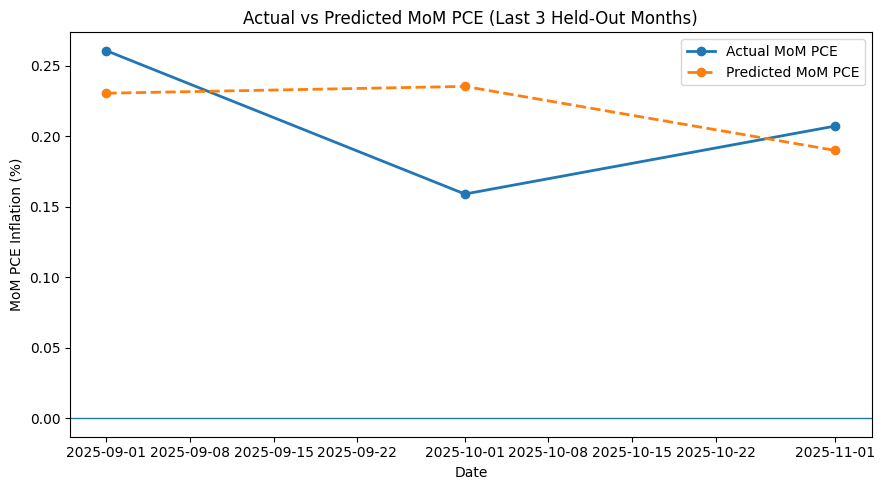

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Make sure Date is datetime
holdout_best = holdout_best.copy()
holdout_best["Date"] = pd.to_datetime(holdout_best["Date"])

plt.figure(figsize=(9, 5))
plt.plot(holdout_best["Date"], holdout_best["Actual_MoM_PCE"], marker="o", linewidth=2, label="Actual MoM PCE")
plt.plot(holdout_best["Date"], holdout_best["Predicted_MoM_PCE"], marker="o", linewidth=2, linestyle="--", label="Predicted MoM PCE")

plt.title("Actual vs Predicted MoM PCE (Last 3 Held-Out Months)")
plt.xlabel("Date")
plt.ylabel("MoM PCE Inflation (%)")
plt.axhline(0, linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ============================================================
# SETTINGS
# ============================================================
DATE_COL = "Period_dt"
TARGET_COL = "pce_mom"

BASE_FEATURES = ["fsbi_comp_lag1", "pce_mom_lag1", "CreditSpreadBAA_lag1"]

# Add one more macro on top of the BAA model
SECOND_MACRO_CANDIDATES = [
    "CreditSpreadGS10",
    "USNaturalGasCompositePrice",
    "Unemployment",
    "CrudeOilPrices",
    "MonetaryCPI",
    "JoltsQuitsRate",
    "ConsumerSentimentIndex",
    "Income",
    "ImportPriceIndex",
]

MIN_TRAIN_N = 60

# ============================================================
# HELPER
# ============================================================
def expanding_oos_forecast(y_vec, X_mat, min_train_n=60):
    T = len(y_vec)
    preds = np.full(T, np.nan)
    for t in range(min_train_n, T):
        y_tr = y_vec[:t]
        X_tr = sm.add_constant(X_mat[:t, :], has_constant="add")
        X_te = sm.add_constant(X_mat[t:t+1, :], has_constant="add")
        res = sm.OLS(y_tr, X_tr).fit()
        preds[t] = float(res.predict(X_te))
    return preds

def evaluate_model(df, target_col, feature_cols, min_train_n=60):
    use_cols = [DATE_COL, target_col] + feature_cols
    d = df[use_cols].dropna().reset_index(drop=True)

    y = d[target_col].to_numpy()
    X = d[feature_cols].to_numpy()
    dates = d[DATE_COL].to_numpy()

    preds = expanding_oos_forecast(y, X, min_train_n=min_train_n)
    mask = ~np.isnan(preds)

    if mask.sum() == 0:
        return None

    mse = mean_squared_error(y[mask], preds[mask])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y[mask], preds[mask])

    return {
        "dates": dates,
        "y": y,
        "preds": preds,
        "mask": mask,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "n_oos": int(mask.sum()),
    }

# ============================================================
# MAKE SURE LAGGED MACROS EXIST
# ============================================================
monthly = monthly.copy().sort_values(DATE_COL).reset_index(drop=True)

for col in SECOND_MACRO_CANDIDATES:
    lag_col = f"{col}_lag1"
    if lag_col not in monthly.columns and col in monthly.columns:
        monthly[lag_col] = monthly[col].shift(1)

# ============================================================
# EVALUATE BASE BAA MODEL
# ============================================================
base_res = evaluate_model(monthly, TARGET_COL, BASE_FEATURES, min_train_n=MIN_TRAIN_N)

print("=== BASE BAA MODEL ===")
print("Features:", BASE_FEATURES)
print(f"OOS MSE : {base_res['mse']:.6f}")
print(f"OOS RMSE: {base_res['rmse']:.6f}")
print(f"OOS MAE : {base_res['mae']:.6f}")

# ============================================================
# TEST ADDING ONE MORE MACRO
# ============================================================
results = []

for macro in SECOND_MACRO_CANDIDATES:
    lag_col = f"{macro}_lag1"
    if lag_col not in monthly.columns:
        continue

    feature_set = BASE_FEATURES + [lag_col]
    res = evaluate_model(monthly, TARGET_COL, feature_set, min_train_n=MIN_TRAIN_N)

    if res is None:
        continue

    results.append({
        "added_macro": macro,
        "features": feature_set,
        "oos_mse": res["mse"],
        "oos_rmse": res["rmse"],
        "oos_mae": res["mae"],
        "mse_reduction_vs_baa_model_pct": (1 - res["mse"] / base_res["mse"]) * 100,
        "rmse_reduction_vs_baa_model_pct": (1 - res["rmse"] / base_res["rmse"]) * 100,
        "n_oos": res["n_oos"],
    })

second_macro_results = pd.DataFrame(results).sort_values("oos_mse").reset_index(drop=True)

print("\n=== ADD ONE MORE MACRO TO BAA MODEL ===")
print(second_macro_results)

# ============================================================
# PICK BEST EXPANDED MODEL
# ============================================================
if not second_macro_results.empty:
    best_added_macro = second_macro_results.iloc[0]["added_macro"]
    best_expanded_features = BASE_FEATURES + [f"{best_added_macro}_lag1"]

    best_expanded_res = evaluate_model(
        monthly, TARGET_COL, best_expanded_features, min_train_n=MIN_TRAIN_N
    )

    print("\n=== BEST EXPANDED MODEL ===")
    print("Added macro:", best_added_macro)
    print("Features:", best_expanded_features)
    print(f"OOS MSE : {best_expanded_res['mse']:.6f}")
    print(f"OOS RMSE: {best_expanded_res['rmse']:.6f}")
    print(f"OOS MAE : {best_expanded_res['mae']:.6f}")
    print(f"MSE reduction vs base BAA model: {(1 - best_expanded_res['mse']/base_res['mse'])*100:.2f}%")
else:
    print("\nNo valid expanded models were estimated.")

=== BASE BAA MODEL ===
Features: ['fsbi_comp_lag1', 'pce_mom_lag1', 'CreditSpreadBAA_lag1']
OOS MSE : 0.011289
OOS RMSE: 0.106251
OOS MAE : 0.083159

=== ADD ONE MORE MACRO TO BAA MODEL ===
                  added_macro  \
0  USNaturalGasCompositePrice   
1                Unemployment   
2      ConsumerSentimentIndex   
3            ImportPriceIndex   
4            CreditSpreadGS10   
5              CrudeOilPrices   
6                      Income   
7              JoltsQuitsRate   
8                 MonetaryCPI   

                                            features   oos_mse  oos_rmse  \
0  [fsbi_comp_lag1, pce_mom_lag1, CreditSpreadBAA...  0.011128  0.105488   
1  [fsbi_comp_lag1, pce_mom_lag1, CreditSpreadBAA...  0.012062  0.109827   
2  [fsbi_comp_lag1, pce_mom_lag1, CreditSpreadBAA...  0.012927  0.113696   
3  [fsbi_comp_lag1, pce_mom_lag1, CreditSpreadBAA...  0.013367  0.115616   
4  [fsbi_comp_lag1, pce_mom_lag1, CreditSpreadBAA...  0.013750  0.117259   
5  [fsbi_comp_lag1, pce

/var/folders/q2/3fx178d13zjcqv_8h929ssxh0000gn/T/ipykernel_44874/3065481872.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds[t] = float(res.predict(X_te))
/var/folders/q2/3fx178d13zjcqv_8h929ssxh0000gn/T/ipykernel_44874/3065481872.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds[t] = float(res.predict(X_te))
/var/folders/q2/3fx178d13zjcqv_8h929ssxh0000gn/T/ipykernel_44874/3065481872.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds[t] =

=== LAST 3 MONTHS HOLDOUT: EXPANDED MODEL ===
        Date  Actual_MoM_PCE  Predicted_MoM_PCE     Error  Abs_Error  Sq_Error
0 2025-09-01        0.260476           0.134256  0.126220   0.126220  0.015931
1 2025-10-01        0.158933           0.168097 -0.009163   0.009163  0.000084
2 2025-11-01        0.207095           0.157436  0.049659   0.049659  0.002466
3-month RMSE (Expanded Model): 0.078489
3-month MAE  (Expanded Model): 0.061681

=== LAST 3 MONTHS HOLDOUT WITH IMPLIED PCE LEVEL: EXPANDED MODEL ===
        Date  Actual_MoM_PCE  Predicted_MoM_PCE     Error  Abs_Error  \
0 2025-09-01        0.260476           0.134256  0.126220   0.126220   
1 2025-10-01        0.158933           0.168097 -0.009163   0.009163   
2 2025-11-01        0.207095           0.157436  0.049659   0.049659   

   Sq_Error  Implied_PCE_Level_Forecast  Actual_PCE_Level  Level_Error  
0  0.015931                  127.464014           127.625     0.160986  
1  0.000084                  127.839714           127

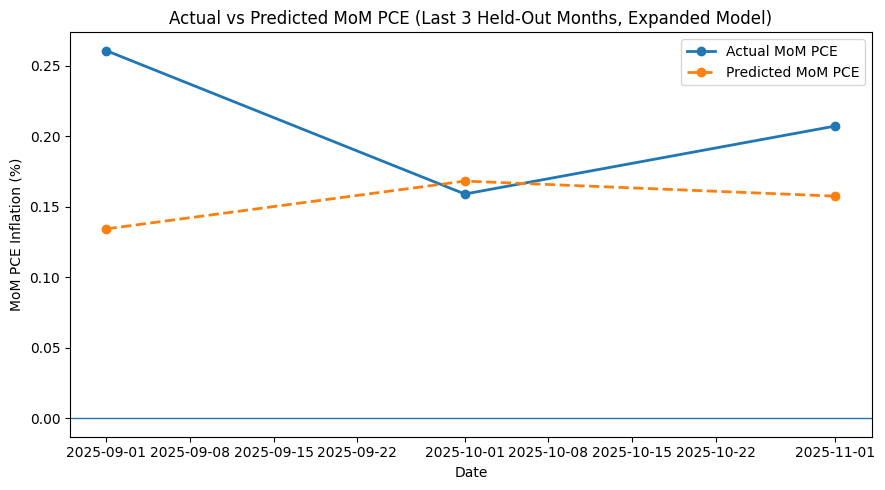

In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

DATE_COL = "Period_dt"
PCE_LEVEL_COL = "PersonalConsumptionExpenditures"

# Expanded model features
expanded_features = [
    "fsbi_comp_lag1",
    "pce_mom_lag1",
    "CreditSpreadBAA_lag1",
    "USNaturalGasCompositePrice_lag1"
]

# ------------------------------------------------------------
# 1) Hold out last 3 months and forecast recursively
# ------------------------------------------------------------
def holdout_last_n_months_forecast(df, target_col, feature_cols, holdout_n=3):
    use_cols = [DATE_COL, target_col] + feature_cols
    d = df[use_cols].dropna().sort_values(DATE_COL).reset_index(drop=True)

    holdout = d.tail(holdout_n).copy()
    preds = []

    for i in range(holdout_n):
        target_date = holdout.iloc[i][DATE_COL]

        train = d[d[DATE_COL] < target_date].copy()
        test = d[d[DATE_COL] == target_date].copy()

        X_train = sm.add_constant(train[feature_cols], has_constant="add")
        y_train = train[target_col]
        X_test = sm.add_constant(test[feature_cols], has_constant="add")
        X_test = X_test[X_train.columns]

        model = sm.OLS(y_train, X_train).fit()
        pred = float(model.predict(X_test).iloc[0])
        actual = float(test[target_col].iloc[0])

        preds.append({
            "Date": target_date,
            "Actual_MoM_PCE": actual,
            "Predicted_MoM_PCE": pred,
            "Error": actual - pred,
            "Abs_Error": abs(actual - pred),
            "Sq_Error": (actual - pred) ** 2
        })

    out = pd.DataFrame(preds)
    rmse = np.sqrt(out["Sq_Error"].mean())
    mae = out["Abs_Error"].mean()
    return out, rmse, mae

holdout_expanded, rmse_expanded_3m, mae_expanded_3m = holdout_last_n_months_forecast(
    monthly,
    target_col="pce_mom",
    feature_cols=expanded_features,
    holdout_n=3
)

print("=== LAST 3 MONTHS HOLDOUT: EXPANDED MODEL ===")
print(holdout_expanded)
print(f"3-month RMSE (Expanded Model): {rmse_expanded_3m:.6f}")
print(f"3-month MAE  (Expanded Model): {mae_expanded_3m:.6f}")

# ------------------------------------------------------------
# 2) Add implied PCE index level forecast
#    Since target is MoM log inflation:
#    P_t_hat = P_{t-1} * exp(pred_mom / 100)
# ------------------------------------------------------------
def add_implied_level_forecast(holdout_df, full_df, level_col):
    full_df = full_df.copy().set_index(DATE_COL)
    out = holdout_df.copy()

    implied_levels = []
    actual_levels = []

    for dt, pred_mom in zip(out["Date"], out["Predicted_MoM_PCE"]):
        prev_dt = pd.to_datetime(dt) - pd.DateOffset(months=1)

        if prev_dt not in full_df.index or pd.to_datetime(dt) not in full_df.index:
            implied_levels.append(np.nan)
            actual_levels.append(np.nan)
            continue

        prev_level = float(full_df.loc[prev_dt, level_col])
        implied_level = prev_level * np.exp(pred_mom / 100.0)
        actual_level = float(full_df.loc[pd.to_datetime(dt), level_col])

        implied_levels.append(implied_level)
        actual_levels.append(actual_level)

    out["Implied_PCE_Level_Forecast"] = implied_levels
    out["Actual_PCE_Level"] = actual_levels
    out["Level_Error"] = out["Actual_PCE_Level"] - out["Implied_PCE_Level_Forecast"]
    return out

holdout_expanded_with_level = add_implied_level_forecast(
    holdout_expanded, monthly, PCE_LEVEL_COL
)

print("\n=== LAST 3 MONTHS HOLDOUT WITH IMPLIED PCE LEVEL: EXPANDED MODEL ===")
print(holdout_expanded_with_level)

# ------------------------------------------------------------
# 3) Plot actual vs predicted MoM PCE
# ------------------------------------------------------------
plot_df = holdout_expanded.copy()
plot_df["Date"] = pd.to_datetime(plot_df["Date"])

plt.figure(figsize=(9, 5))
plt.plot(
    plot_df["Date"],
    plot_df["Actual_MoM_PCE"],
    marker="o",
    linewidth=2,
    label="Actual MoM PCE"
)
plt.plot(
    plot_df["Date"],
    plot_df["Predicted_MoM_PCE"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Predicted MoM PCE"
)
plt.axhline(0, linewidth=1)
plt.title("Actual vs Predicted MoM PCE (Last 3 Held-Out Months, Expanded Model)")
plt.xlabel("Date")
plt.ylabel("MoM PCE Inflation (%)")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

DATE_COL = "Period_dt"
TARGET_COL = "pce_mom"
PCE_LEVEL_COL = "PersonalConsumptionExpenditures"

# ------------------------------------------------------------
# 1) Make sure target and lags exist
# ------------------------------------------------------------
monthly = monthly.copy().sort_values(DATE_COL).reset_index(drop=True)

if "pce_mom" not in monthly.columns:
    monthly["pce_mom"] = 100 * (
        np.log(monthly[PCE_LEVEL_COL]) - np.log(monthly[PCE_LEVEL_COL].shift(1))
    )

if "pce_mom_lag1" not in monthly.columns:
    monthly["pce_mom_lag1"] = monthly["pce_mom"].shift(1)

if "fsbi_comp_lag1" not in monthly.columns:
    monthly["fsbi_comp_lag1"] = monthly["fsbi_comp"].shift(1)

# ------------------------------------------------------------
# 2) Current best model
# ------------------------------------------------------------
BASE_FEATURES = [
    "fsbi_comp_lag1",
    "pce_mom_lag1",
    "CreditSpreadBAA_lag1",
    "USNaturalGasCompositePrice_lag1",
]

# Candidates to add on top of that
THIRD_MACRO_CANDIDATES = [
    "CreditSpreadGS10",
    "Unemployment",
    "CrudeOilPrices",
    "MonetaryCPI",
    "JoltsQuitsRate",
    "ConsumerSentimentIndex",
    "Income",
    "ImportPriceIndex",
]

# Build lag1 versions if missing
for col in THIRD_MACRO_CANDIDATES:
    lag_col = f"{col}_lag1"
    if lag_col not in monthly.columns and col in monthly.columns:
        monthly[lag_col] = monthly[col].shift(1)

# ------------------------------------------------------------
# 3) Helpers
# ------------------------------------------------------------
def expanding_oos_forecast(y_vec, X_mat, min_train_n=60):
    T = len(y_vec)
    preds = np.full(T, np.nan)
    for t in range(min_train_n, T):
        y_tr = y_vec[:t]
        X_tr = sm.add_constant(X_mat[:t, :], has_constant="add")
        X_te = sm.add_constant(X_mat[t:t+1, :], has_constant="add")
        res = sm.OLS(y_tr, X_tr).fit()
        preds[t] = res.predict(X_te).item()
    return preds

def evaluate_model(df, target_col, feature_cols, min_train_n=60):
    d = df[[DATE_COL, target_col] + feature_cols].dropna().reset_index(drop=True)

    y = d[target_col].to_numpy()
    X = d[feature_cols].to_numpy()

    preds = expanding_oos_forecast(y, X, min_train_n=min_train_n)
    mask = ~np.isnan(preds)

    if mask.sum() == 0:
        return None

    mse = mean_squared_error(y[mask], preds[mask])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y[mask], preds[mask])

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "n_oos": int(mask.sum()),
        "preds": preds,
        "mask": mask,
        "dates": d[DATE_COL].to_numpy(),
        "y": y,
    }

# ------------------------------------------------------------
# 4) Evaluate current base model
# ------------------------------------------------------------
MIN_TRAIN_N = 60

base_res = evaluate_model(monthly, TARGET_COL, BASE_FEATURES, min_train_n=MIN_TRAIN_N)

print("=== CURRENT BASE MODEL ===")
print("Features:", BASE_FEATURES)
print(f"OOS MSE : {base_res['mse']:.6f}")
print(f"OOS RMSE: {base_res['rmse']:.6f}")
print(f"OOS MAE : {base_res['mae']:.6f}")

# ------------------------------------------------------------
# 5) Add one more macro on top
# ------------------------------------------------------------
results = []

for macro in THIRD_MACRO_CANDIDATES:
    lag_col = f"{macro}_lag1"
    if lag_col not in monthly.columns:
        continue

    feature_set = BASE_FEATURES + [lag_col]
    res = evaluate_model(monthly, TARGET_COL, feature_set, min_train_n=MIN_TRAIN_N)

    if res is None:
        continue

    results.append({
        "added_macro": macro,
        "features": feature_set,
        "oos_mse": res["mse"],
        "oos_rmse": res["rmse"],
        "oos_mae": res["mae"],
        "mse_reduction_vs_current_model_pct": (1 - res["mse"] / base_res["mse"]) * 100,
        "rmse_reduction_vs_current_model_pct": (1 - res["rmse"] / base_res["rmse"]) * 100,
        "n_oos": res["n_oos"],
    })

third_macro_results = pd.DataFrame(results).sort_values("oos_mse").reset_index(drop=True)

print("\n=== ADD ONE MORE MACRO TO CURRENT MODEL ===")
print(third_macro_results)

# ------------------------------------------------------------
# 6) Pick best final model
# ------------------------------------------------------------
if not third_macro_results.empty:
    best_added_macro = third_macro_results.iloc[0]["added_macro"]
    FINAL_FEATURES = BASE_FEATURES + [f"{best_added_macro}_lag1"]
else:
    best_added_macro = None
    FINAL_FEATURES = BASE_FEATURES

print("\nBest added macro:", best_added_macro)
print("Final features:", FINAL_FEATURES)

# ------------------------------------------------------------
# 7) Fit final model on all available data and produce current MoM forecast
# ------------------------------------------------------------
final_df = monthly[[DATE_COL, TARGET_COL] + FINAL_FEATURES].dropna().reset_index(drop=True)

X_final = sm.add_constant(final_df[FINAL_FEATURES], has_constant="add")
y_final = final_df[TARGET_COL]

final_model = sm.OLS(y_final, X_final).fit()

print("\n=== FINAL MODEL SUMMARY ===")
print(final_model.summary())

# Forecast the latest available month in your data
latest_row = final_df.iloc[-1]

X_now = pd.DataFrame([{"const": 1.0, **{c: latest_row[c] for c in FINAL_FEATURES}}])
X_now = X_now[final_model.model.exog_names]

current_mom_forecast = final_model.predict(X_now).item()

print("\n=== CURRENT MoM PCE FORECAST ===")
print("Forecast month:", pd.to_datetime(latest_row[DATE_COL]).date())
print("Predicted MoM PCE (%):", round(current_mom_forecast, 4))

=== CURRENT BASE MODEL ===
Features: ['fsbi_comp_lag1', 'pce_mom_lag1', 'CreditSpreadBAA_lag1', 'USNaturalGasCompositePrice_lag1']
OOS MSE : 0.011128
OOS RMSE: 0.105488
OOS MAE : 0.087828

=== ADD ONE MORE MACRO TO CURRENT MODEL ===
              added_macro                                           features  \
0  ConsumerSentimentIndex  [fsbi_comp_lag1, pce_mom_lag1, CreditSpreadBAA...   
1          CrudeOilPrices  [fsbi_comp_lag1, pce_mom_lag1, CreditSpreadBAA...   
2            Unemployment  [fsbi_comp_lag1, pce_mom_lag1, CreditSpreadBAA...   
3        ImportPriceIndex  [fsbi_comp_lag1, pce_mom_lag1, CreditSpreadBAA...   
4        CreditSpreadGS10  [fsbi_comp_lag1, pce_mom_lag1, CreditSpreadBAA...   
5          JoltsQuitsRate  [fsbi_comp_lag1, pce_mom_lag1, CreditSpreadBAA...   
6             MonetaryCPI  [fsbi_comp_lag1, pce_mom_lag1, CreditSpreadBAA...   
7                  Income  [fsbi_comp_lag1, pce_mom_lag1, CreditSpreadBAA...   

    oos_mse  oos_rmse   oos_mae  mse_reduction

In [14]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

DATE_COL = "Period_dt"
TARGET_COL = "pce_mom"
PCE_LEVEL_COL = "PersonalConsumptionExpenditures"

FOUR_VAR_FEATURES = [
    "fsbi_comp_lag1",
    "pce_mom_lag1",
    "CreditSpreadBAA_lag1",
    "USNaturalGasCompositePrice_lag1",
]

# --------------------------------------
# 1) Ensure target and lagged features exist
# --------------------------------------
monthly = monthly.copy().sort_values(DATE_COL).reset_index(drop=True)

if "pce_mom" not in monthly.columns:
    monthly["pce_mom"] = 100 * (
        np.log(monthly[PCE_LEVEL_COL]) - np.log(monthly[PCE_LEVEL_COL].shift(1))
    )

if "pce_mom_lag1" not in monthly.columns:
    monthly["pce_mom_lag1"] = monthly["pce_mom"].shift(1)

if "fsbi_comp_lag1" not in monthly.columns:
    monthly["fsbi_comp_lag1"] = monthly["fsbi_comp"].shift(1)

if "CreditSpreadBAA_lag1" not in monthly.columns:
    monthly["CreditSpreadBAA_lag1"] = monthly["CreditSpreadBAA"].shift(1)

if "USNaturalGasCompositePrice_lag1" not in monthly.columns:
    monthly["USNaturalGasCompositePrice_lag1"] = monthly["USNaturalGasCompositePrice"].shift(1)

# --------------------------------------
# 2) Build final modeling dataframe
# --------------------------------------
nowcast_df = monthly[[DATE_COL, TARGET_COL] + FOUR_VAR_FEATURES].dropna().reset_index(drop=True)

print("Nowcast sample ends at:", nowcast_df[DATE_COL].iloc[-1].date())
print("Number of usable rows:", len(nowcast_df))

# --------------------------------------
# 3) Fit model on all available data
# --------------------------------------
X_train = sm.add_constant(nowcast_df[FOUR_VAR_FEATURES], has_constant="add")
y_train = nowcast_df[TARGET_COL]

final_model_4 = sm.OLS(y_train, X_train).fit()

print(final_model_4.summary())

# --------------------------------------
# 4) Produce current nowcast
# --------------------------------------
latest_row = nowcast_df.iloc[-1]

X_now = pd.DataFrame([{
    "const": 1.0,
    "fsbi_comp_lag1": latest_row["fsbi_comp_lag1"],
    "pce_mom_lag1": latest_row["pce_mom_lag1"],
    "CreditSpreadBAA_lag1": latest_row["CreditSpreadBAA_lag1"],
    "USNaturalGasCompositePrice_lag1": latest_row["USNaturalGasCompositePrice_lag1"],
}])

X_now = X_now[final_model_4.model.exog_names]

current_mom_nowcast = final_model_4.predict(X_now).item()

print("\n=== CURRENT MoM PCE NOWCAST (4-variable model) ===")
print("Forecast month:", pd.to_datetime(latest_row[DATE_COL]).date())
print("Predicted MoM PCE (%):", round(current_mom_nowcast, 4))


Nowcast sample ends at: 2025-11-01
Number of usable rows: 81
                            OLS Regression Results                            
Dep. Variable:                pce_mom   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.464
Method:                 Least Squares   F-statistic:                     18.33
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.40e-10
Time:                        20:53:06   Log-Likelihood:                 35.956
No. Observations:                  81   AIC:                            -61.91
Df Residuals:                      76   BIC:                            -49.94
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

In [15]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

DATE_COL = "Period_dt"
TARGET_COL = "pce_mom"
PCE_LEVEL_COL = "PersonalConsumptionExpenditures"

FOUR_VAR_FEATURES = [
    "fsbi_comp_lag1",
    "pce_mom_lag1",
    "CreditSpreadBAA_lag1",
    "USNaturalGasCompositePrice_lag1",
]

TRAIN_N = 76

# ---------------------------------------------------
# 1) Ensure variables exist
# ---------------------------------------------------
monthly = monthly.copy().sort_values(DATE_COL).reset_index(drop=True)

if "pce_mom" not in monthly.columns:
    monthly["pce_mom"] = 100 * (
        np.log(monthly[PCE_LEVEL_COL]) - np.log(monthly[PCE_LEVEL_COL].shift(1))
    )

if "pce_mom_lag1" not in monthly.columns:
    monthly["pce_mom_lag1"] = monthly["pce_mom"].shift(1)

if "fsbi_comp_lag1" not in monthly.columns:
    monthly["fsbi_comp_lag1"] = monthly["fsbi_comp"].shift(1)

if "CreditSpreadBAA_lag1" not in monthly.columns:
    monthly["CreditSpreadBAA_lag1"] = monthly["CreditSpreadBAA"].shift(1)

if "USNaturalGasCompositePrice_lag1" not in monthly.columns:
    monthly["USNaturalGasCompositePrice_lag1"] = monthly["USNaturalGasCompositePrice"].shift(1)

# ---------------------------------------------------
# 2) Build modeling dataframe
# ---------------------------------------------------
model_df = monthly[[DATE_COL, TARGET_COL] + FOUR_VAR_FEATURES].dropna().reset_index(drop=True)

print("Total usable observations:", len(model_df))
print("Start:", model_df[DATE_COL].iloc[0].date())
print("End  :", model_df[DATE_COL].iloc[-1].date())

train_df = model_df.iloc[:TRAIN_N].copy()
test_df = model_df.iloc[TRAIN_N:].copy()

print("\nTraining sample:")
print(train_df[DATE_COL].iloc[0].date(), "to", train_df[DATE_COL].iloc[-1].date())
print("Rows:", len(train_df))

print("\nTest sample:")
print(test_df[DATE_COL].iloc[0].date(), "to", test_df[DATE_COL].iloc[-1].date())
print("Rows:", len(test_df))

# ---------------------------------------------------
# 3) Fit model on training set and get in-sample train fit
# ---------------------------------------------------
X_train = sm.add_constant(train_df[FOUR_VAR_FEATURES], has_constant="add")
y_train = train_df[TARGET_COL]

train_model = sm.OLS(y_train, X_train).fit()
train_df["Predicted_Train_MoM_PCE"] = train_model.predict(X_train)

print("\n=== TRAIN MODEL SUMMARY ===")
print(train_model.summary())

# ---------------------------------------------------
# 4) Recursive one-step-ahead forecasts on test set
# ---------------------------------------------------
preds = []

for i in range(len(test_df)):
    target_date = test_df.iloc[i][DATE_COL]

    current_train = model_df[model_df[DATE_COL] < target_date].copy()
    current_test = model_df[model_df[DATE_COL] == target_date].copy()

    X_tr = sm.add_constant(current_train[FOUR_VAR_FEATURES], has_constant="add")
    y_tr = current_train[TARGET_COL]

    X_te = sm.add_constant(current_test[FOUR_VAR_FEATURES], has_constant="add")
    X_te = X_te[X_tr.columns]

    model = sm.OLS(y_tr, X_tr).fit()
    pred = model.predict(X_te).item()
    actual = current_test[TARGET_COL].iloc[0]

    preds.append({
        "Date": target_date,
        "Actual_MoM_PCE": actual,
        "Predicted_Test_MoM_PCE": pred,
        "Error": actual - pred,
        "Abs_Error": abs(actual - pred),
        "Sq_Error": (actual - pred) ** 2,
    })

test_results = pd.DataFrame(preds)

# ---------------------------------------------------
# 5) Test metrics
# ---------------------------------------------------
test_mse  = test_results["Sq_Error"].mean()
test_rmse = np.sqrt(test_mse)
test_mae  = test_results["Abs_Error"].mean()
test_da   = directional_accuracy(test_results["Actual_MoM_PCE"], test_results["Predicted_MoM_PCE"])
test_mape = mape(test_results["Actual_MoM_PCE"], test_results["Predicted_MoM_PCE"])

print("\n=== TEST RESULTS (76 train / rest test) ===")
print(f"Test MSE : {test_mse:.6f}")
print(f"Test RMSE: {test_rmse:.6f}")
print(f"Test MAE : {test_mae:.6f}")

print("\nTest predictions:")
print(test_results)

# ---------------------------------------------------
# 6) Combined plot: train fit + test forecast
# ---------------------------------------------------
plt.figure(figsize=(11, 6))

# Actual full series
plt.plot(
    model_df[DATE_COL],
    model_df[TARGET_COL],
    linewidth=2,
    label="Actual MoM PCE"
)

# Train fitted values
plt.plot(
    train_df[DATE_COL],
    train_df["Predicted_Train_MoM_PCE"],
    linestyle="--",
    linewidth=2,
    label="Train fitted values"
)

# Test forecasts
plt.plot(
    test_results["Date"],
    test_results["Predicted_Test_MoM_PCE"],
    linestyle="--",
    linewidth=2,
    marker="o",
    label="Test forecasts"
)

# Split line
plt.axvline(train_df[DATE_COL].iloc[-1], linewidth=1)

plt.title("MoM PCE: Actual vs Train Fit and Test Forecasts")
plt.xlabel("Date")
plt.ylabel("MoM PCE Inflation (%)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 7) Test-only plot
# ---------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(
    test_results["Date"],
    test_results["Actual_MoM_PCE"],
    marker="o",
    linewidth=2,
    label="Actual MoM PCE"
)
plt.plot(
    test_results["Date"],
    test_results["Predicted_Test_MoM_PCE"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Predicted MoM PCE"
)
plt.axhline(0, linewidth=1)
plt.title("Test Period Only: Actual vs Predicted MoM PCE")
plt.xlabel("Date")
plt.ylabel("MoM PCE Inflation (%)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 8) Error plot for test period
# ---------------------------------------------------
plt.figure(figsize=(10, 5))
plt.bar(
    test_results["Date"].dt.strftime("%Y-%m"),
    test_results["Error"]
)
plt.axhline(0, linewidth=1)
plt.title("Test Period Forecast Errors: Actual - Predicted")
plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.tight_layout()
plt.show()

Total usable observations: 81
Start: 2019-03-01
End  : 2025-11-01

Training sample:
2019-03-01 to 2025-06-01
Rows: 76

Test sample:
2025-07-01 to 2025-11-01
Rows: 5

=== TRAIN MODEL SUMMARY ===
                            OLS Regression Results                            
Dep. Variable:                pce_mom   R-squared:                       0.495
Model:                            OLS   Adj. R-squared:                  0.466
Method:                 Least Squares   F-statistic:                     17.39
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           5.49e-10
Time:                        20:53:06   Log-Likelihood:                 31.879
No. Observations:                  76   AIC:                            -53.76
Df Residuals:                      71   BIC:                            -42.10
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                

KeyError: 'Predicted_MoM_PCE'

=== MODEL COMPARISON: 76 / rest split ===
                 model                                           features  \
0           FSBI + BAA    [pce_mom_lag1, fsbi_comp, CreditSpreadBAA_lag1]   
1                AR(1)                                     [pce_mom_lag1]   
2                 FSBI                          [pce_mom_lag1, fsbi_comp]   
3        Nowcast-style  [pce_mom_lag1, fsbi_comp, CreditSpreadBAA, USN...   
4  FSBI + BAA + NatGas  [pce_mom_lag1, fsbi_comp_lag1, CreditSpreadBAA...   

   test_mse  test_rmse  test_mae  n_train  n_test  
0  0.004328   0.065788  0.061609       76       5  
1  0.005176   0.071944  0.054844       76       5  
2  0.005381   0.073357  0.056627       76       5  
3  0.005704   0.075523  0.054436       76       4  
4  0.005963   0.077223  0.062838       76       5  


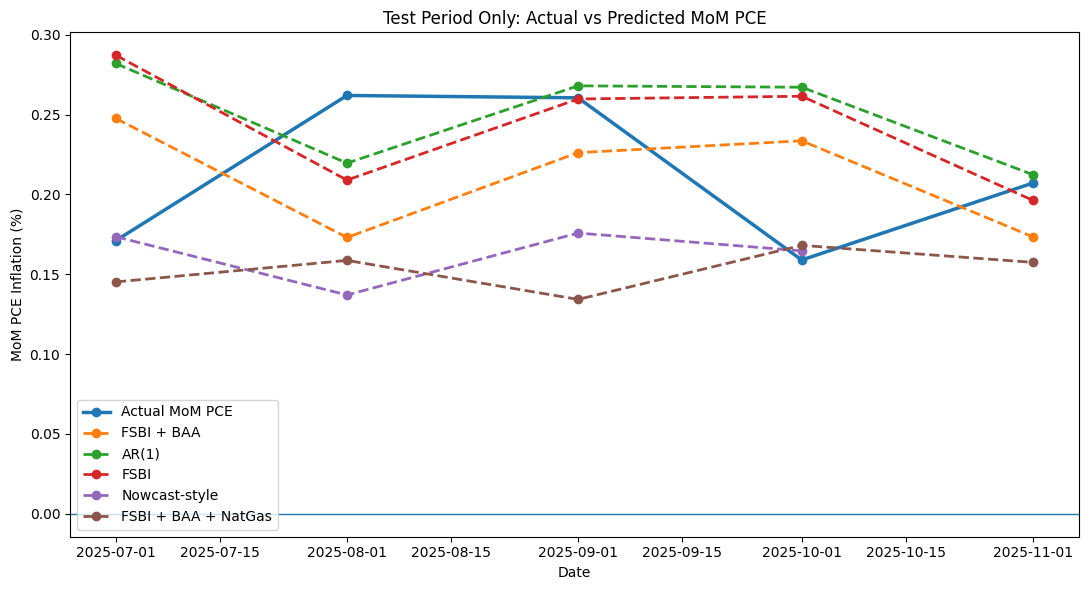

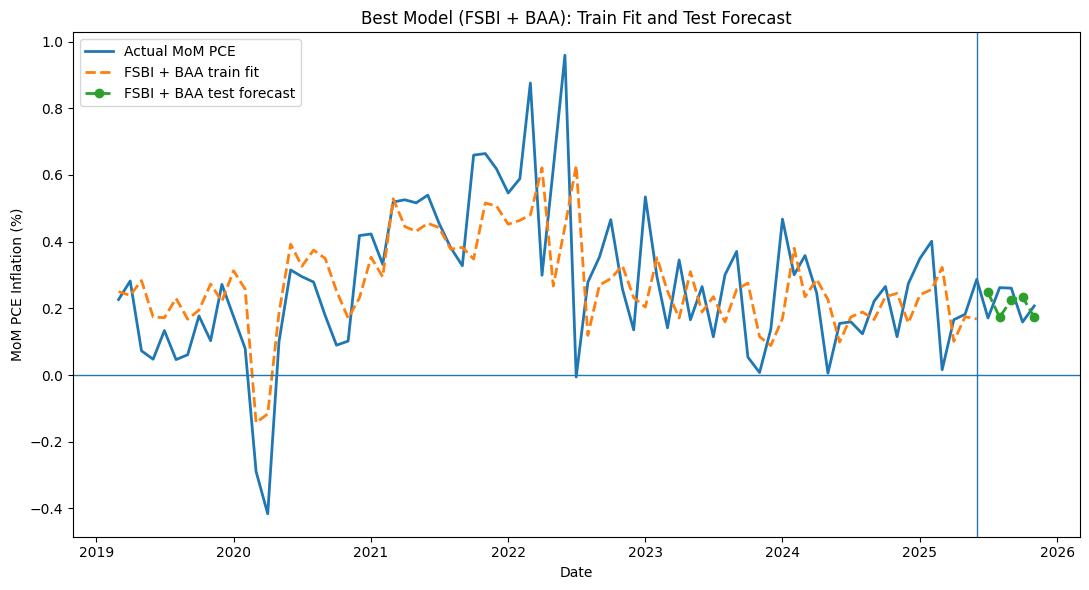


=== FSBI + BAA test predictions ===
        Date  Actual_MoM_PCE  Predicted_MoM_PCE     Error
0 2025-07-01        0.171066           0.247571 -0.076505
1 2025-08-01        0.261944           0.173024  0.088920
2 2025-09-01        0.260476           0.226146  0.034330
3 2025-10-01        0.158933           0.233559 -0.074625
4 2025-11-01        0.207095           0.173431  0.033665

=== AR(1) test predictions ===
        Date  Actual_MoM_PCE  Predicted_MoM_PCE     Error
0 2025-07-01        0.171066           0.281962 -0.110896
1 2025-08-01        0.261944           0.219574  0.042369
2 2025-09-01        0.260476           0.267976 -0.007500
3 2025-10-01        0.158933           0.267110 -0.108177
4 2025-11-01        0.207095           0.212370 -0.005275

=== FSBI test predictions ===
        Date  Actual_MoM_PCE  Predicted_MoM_PCE     Error
0 2025-07-01        0.171066           0.287121 -0.116055
1 2025-08-01        0.261944           0.208948  0.052996
2 2025-09-01        0.260476  

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =========================================================
# Compare MoM models on the same 76 / rest time split
# Models:
# 1) AR(1)
# 2) FSBI-only
# 3) FSBI + BAA
# 4) FSBI + BAA + NatGas
# Optional:
# 5) nowcast-style contemporaneous fast variables
# =========================================================

DATE_COL = "Period_dt"
PCE_LEVEL_COL = "PersonalConsumptionExpenditures"
TRAIN_N = 76

monthly = monthly.copy().sort_values(DATE_COL).reset_index(drop=True)

# -----------------------------
# 1) Build target and regressors
# -----------------------------
if "pce_mom" not in monthly.columns:
    monthly["pce_mom"] = 100 * (
        np.log(monthly[PCE_LEVEL_COL]) - np.log(monthly[PCE_LEVEL_COL].shift(1))
    )

if "pce_mom_lag1" not in monthly.columns:
    monthly["pce_mom_lag1"] = monthly["pce_mom"].shift(1)

# fsbi_comp should already exist from earlier work; if not, rebuild it here
if "fsbi_comp" not in monthly.columns:
    SALES_MOM_COL = "Real Sales MOM % - SA"
    TXN_MOM_COL = "Transaction MOM % - SA"
    SALES_IDX_COL = "Real Sales Index - SA"
    TXN_IDX_COL = "Transactional Index - SA"

    use_mom_cols = (SALES_MOM_COL in monthly.columns) and (TXN_MOM_COL in monthly.columns)

    if use_mom_cols:
        monthly["fsbi_sales_signal"] = monthly[SALES_MOM_COL]
        monthly["fsbi_txn_signal"] = monthly[TXN_MOM_COL]
    else:
        monthly["fsbi_sales_signal"] = monthly[SALES_IDX_COL] - monthly[SALES_IDX_COL].shift(1)
        monthly["fsbi_txn_signal"] = monthly[TXN_IDX_COL] - monthly[TXN_IDX_COL].shift(1)

    monthly["fsbi_comp"] = (
        (monthly["fsbi_sales_signal"] - monthly["fsbi_sales_signal"].mean()) / monthly["fsbi_sales_signal"].std(ddof=0)
        + (monthly["fsbi_txn_signal"] - monthly["fsbi_txn_signal"].mean()) / monthly["fsbi_txn_signal"].std(ddof=0)
    ) * 12.0

for col in ["fsbi_comp", "CreditSpreadBAA", "USNaturalGasCompositePrice", "CrudeOilPrices"]:
    lag_col = f"{col}_lag1"
    if lag_col not in monthly.columns and col in monthly.columns:
        monthly[lag_col] = monthly[col].shift(1)

# -----------------------------
# 2) Define model specs
# -----------------------------
MODEL_SPECS = {
    "AR(1)": ["pce_mom_lag1"],
    "FSBI": ["pce_mom_lag1", "fsbi_comp"],
    "FSBI + BAA": ["pce_mom_lag1", "fsbi_comp", "CreditSpreadBAA_lag1"],
    "FSBI + BAA + NatGas": ["pce_mom_lag1", "fsbi_comp_lag1", "CreditSpreadBAA_lag1", "USNaturalGasCompositePrice_lag1"],
    # Optional nowcast-style spec using contemporaneous fast variables:
    "Nowcast-style": ["pce_mom_lag1", "fsbi_comp", "CreditSpreadBAA", "USNaturalGasCompositePrice"],
}

# -----------------------------
# 3) Helper to evaluate one model
# -----------------------------
def evaluate_time_split(df, feature_cols, train_n=76):
    use_cols = [DATE_COL, "pce_mom"] + feature_cols
    d = df[use_cols].dropna().reset_index(drop=True)

    if len(d) <= train_n:
        return None

    train = d.iloc[:train_n].copy()
    test = d.iloc[train_n:].copy()

    # In-sample fit on train
    X_train = sm.add_constant(train[feature_cols], has_constant="add")
    y_train = train["pce_mom"]
    train_model = sm.OLS(y_train, X_train).fit()
    train_fitted = train_model.predict(X_train)

    # Recursive one-step-ahead forecasts on test
    preds = []
    for i in range(len(test)):
        target_date = test.iloc[i][DATE_COL]

        current_train = d[d[DATE_COL] < target_date].copy()
        current_test = d[d[DATE_COL] == target_date].copy()

        X_tr = sm.add_constant(current_train[feature_cols], has_constant="add")
        y_tr = current_train["pce_mom"]

        X_te = sm.add_constant(current_test[feature_cols], has_constant="add")
        X_te = X_te[X_tr.columns]

        model = sm.OLS(y_tr, X_tr).fit()
        pred = model.predict(X_te).item()
        actual = current_test["pce_mom"].iloc[0]

        preds.append({
            "Date": target_date,
            "Actual_MoM_PCE": actual,
            "Predicted_MoM_PCE": pred,
            "Error": actual - pred,
            "Abs_Error": abs(actual - pred),
            "Sq_Error": (actual - pred) ** 2,
        })

    test_results = pd.DataFrame(preds)

    test_mse  = test_results["Sq_Error"].mean()
    test_rmse = np.sqrt(test_mse)
    test_mae  = test_results["Abs_Error"].mean()
    test_da   = directional_accuracy(test_results["Actual_MoM_PCE"], test_results["Predicted_MoM_PCE"])
    test_mape = mape(test_results["Actual_MoM_PCE"], test_results["Predicted_MoM_PCE"])

    return {
        "data": d,
        "train": train,
        "test": test,
        "train_model": train_model,
        "train_fitted": train_fitted,
        "test_results": test_results,
        "test_mse": test_mse,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_da": test_da,
        "test_mape": test_mape,
        "n_train": len(train),
        "n_test": len(test),
    }

# -----------------------------
# 4) Run all models
# -----------------------------
all_results = {}
summary_rows = []

for model_name, feats in MODEL_SPECS.items():
    res = evaluate_time_split(monthly, feats, train_n=TRAIN_N)
    if res is None:
        continue
    all_results[model_name] = res
    summary_rows.append({
        "model": model_name,
        "features": feats,
        "test_mse": res["test_mse"],
        "test_rmse": res["test_rmse"],
        "test_mae": res["test_mae"],
        "test_da_pct": res["test_da"],
        "test_mape_pct": res["test_mape"],
        "n_train": res["n_train"],
        "n_test": res["n_test"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("test_mse").reset_index(drop=True)

print("=== MODEL COMPARISON: 76 / rest split ===")
print(summary_df)

# -----------------------------
# 5) Plot test-period forecasts together
# -----------------------------
plt.figure(figsize=(11, 6))

# Use first model's test dates as reference
first_model = summary_df.loc[0, "model"]
ref_test = all_results[first_model]["test_results"]

plt.plot(
    ref_test["Date"],
    ref_test["Actual_MoM_PCE"],
    marker="o",
    linewidth=2.5,
    label="Actual MoM PCE"
)

for model_name in summary_df["model"]:
    tr = all_results[model_name]["test_results"]
    plt.plot(
        tr["Date"],
        tr["Predicted_MoM_PCE"],
        marker="o",
        linestyle="--",
        linewidth=2,
        label=model_name
    )

plt.axhline(0, linewidth=1)
plt.title("Test Period Only: Actual vs Predicted MoM PCE")
plt.xlabel("Date")
plt.ylabel("MoM PCE Inflation (%)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 6) Plot train fit + test forecast for best model
# -----------------------------
best_model_name = summary_df.loc[0, "model"]
best_res = all_results[best_model_name]

plt.figure(figsize=(11, 6))

plt.plot(
    best_res["data"][DATE_COL],
    best_res["data"]["pce_mom"],
    linewidth=2,
    label="Actual MoM PCE"
)

plt.plot(
    best_res["train"][DATE_COL],
    best_res["train_fitted"],
    linestyle="--",
    linewidth=2,
    label=f"{best_model_name} train fit"
)

plt.plot(
    best_res["test_results"]["Date"],
    best_res["test_results"]["Predicted_MoM_PCE"],
    linestyle="--",
    linewidth=2,
    marker="o",
    label=f"{best_model_name} test forecast"
)

plt.axvline(best_res["train"][DATE_COL].iloc[-1], linewidth=1)
plt.axhline(0, linewidth=1)
plt.title(f"Best Model ({best_model_name}): Train Fit and Test Forecast")
plt.xlabel("Date")
plt.ylabel("MoM PCE Inflation (%)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 7) Optional: print per-model test predictions
# -----------------------------
for model_name in summary_df["model"]:
    print(f"\n=== {model_name} test predictions ===")
    print(all_results[model_name]["test_results"][["Date", "Actual_MoM_PCE", "Predicted_MoM_PCE", "Error"]])

In [18]:
plot_df = model_df[[DATE_COL, "pce_mom", "predicted_same_row"]].copy()

# shift prediction one month BACK on the plot
plot_df["predicted_shifted_back"] = plot_df["predicted_same_row"].shift(-1)

plt.figure(figsize=(11, 6))
plt.plot(plot_df[DATE_COL], plot_df["pce_mom"], linewidth=2, label="Actual MoM PCE")
plt.plot(
    plot_df[DATE_COL],
    plot_df["predicted_shifted_back"],
    linestyle="--",
    linewidth=2,
    marker="o",
    label="Lagged-model forecast (shifted back 1 month)"
)
plt.axhline(0, linewidth=1)
plt.title("MoM PCE: Actual vs Lagged Forecast Shifted Back 1 Month")
plt.xlabel("Date")
plt.ylabel("MoM PCE Inflation (%)")
plt.legend()
plt.tight_layout()
plt.show()

KeyError: "['predicted_same_row'] not in index"

Total usable observations: 81
Start: 2019-02-01
End  : 2025-10-01

Training sample:
2019-02-01 to 2025-05-01
Rows: 76

Test sample:
2025-06-01 to 2025-10-01
Rows: 5

=== NOWCAST MODEL SUMMARY ===
                            OLS Regression Results                            
Dep. Variable:                pce_mom   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.571
Method:                 Least Squares   F-statistic:                     34.30
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           7.04e-14
Time:                        22:58:22   Log-Likelihood:                 39.572
No. Observations:                  76   AIC:                            -71.14
Df Residuals:                      72   BIC:                            -61.82
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
              

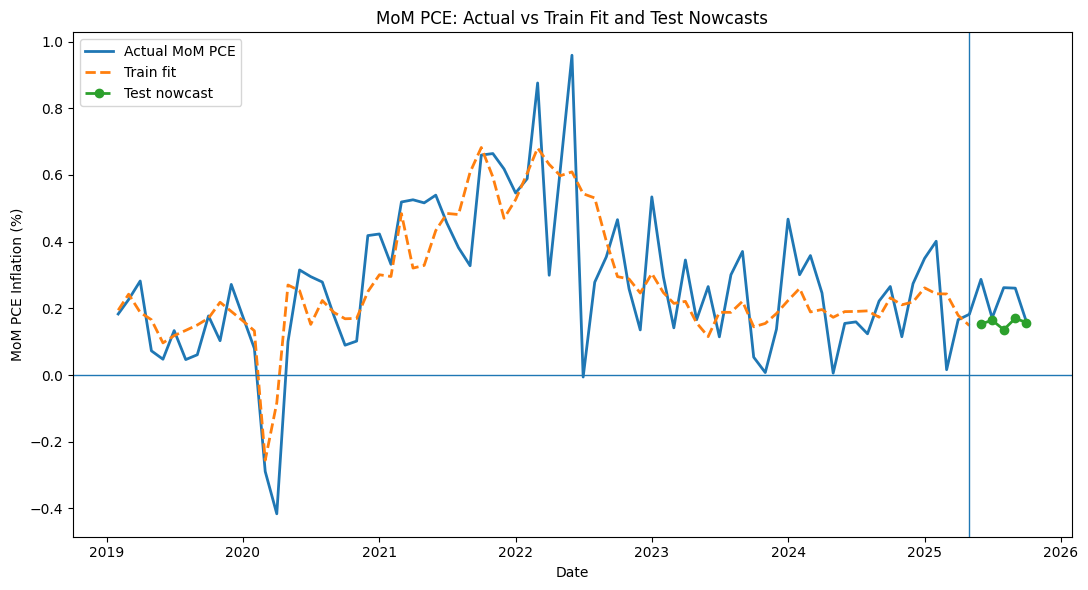

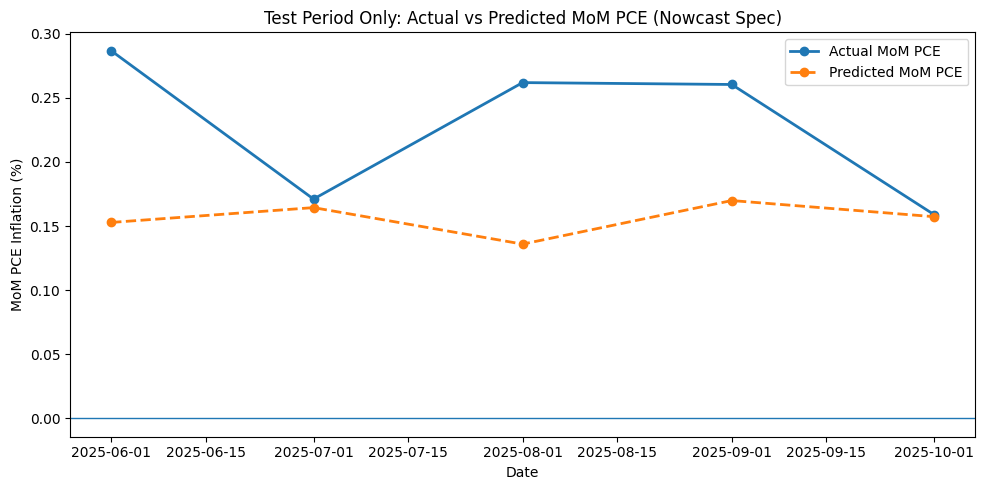

In [25]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

DATE_COL = "Period_dt"
PCE_LEVEL_COL = "PersonalConsumptionExpenditures"
TARGET_COL = "pce_mom"
TRAIN_N = 76

# ---------------------------------------------------
# 1) Ensure target + regressors exist
# ---------------------------------------------------
monthly = monthly.copy().sort_values(DATE_COL).reset_index(drop=True)

if "pce_mom" not in monthly.columns:
    monthly["pce_mom"] = 100 * (
        np.log(monthly[PCE_LEVEL_COL]) - np.log(monthly[PCE_LEVEL_COL].shift(1))
    )

if "pce_mom_lag1" not in monthly.columns:
    monthly["pce_mom_lag1"] = monthly["pce_mom"].shift(1)

if "fsbi_comp" not in monthly.columns:
    SALES_MOM_COL = "Real Sales MOM % - SA"
    TXN_MOM_COL = "Transaction MOM % - SA"
    SALES_IDX_COL = "Real Sales Index - SA"
    TXN_IDX_COL = "Transactional Index - SA"

    use_mom_cols = (SALES_MOM_COL in monthly.columns) and (TXN_MOM_COL in monthly.columns)

    if use_mom_cols:
        monthly["fsbi_sales_signal"] = monthly[SALES_MOM_COL]
        monthly["fsbi_txn_signal"] = monthly[TXN_MOM_COL]
    else:
        monthly["fsbi_sales_signal"] = monthly[SALES_IDX_COL] - monthly[SALES_IDX_COL].shift(1)
        monthly["fsbi_txn_signal"] = monthly[TXN_IDX_COL] - monthly[TXN_IDX_COL].shift(1)

    monthly["fsbi_comp"] = (
        (monthly["fsbi_sales_signal"] - monthly["fsbi_sales_signal"].mean()) / monthly["fsbi_sales_signal"].std(ddof=0)
        + (monthly["fsbi_txn_signal"] - monthly["fsbi_txn_signal"].mean()) / monthly["fsbi_txn_signal"].std(ddof=0)
    ) * 12.0

# ---------------------------------------------------
# 2) Define nowcast model
# ---------------------------------------------------
NOWCAST_FEATURES = [
    "fsbi_comp",
    "CreditSpreadBAA",
    "USNaturalGasCompositePrice",
]

model_df = monthly[[DATE_COL, TARGET_COL] + NOWCAST_FEATURES].dropna().reset_index(drop=True)

print("Total usable observations:", len(model_df))
print("Start:", model_df[DATE_COL].iloc[0].date())
print("End  :", model_df[DATE_COL].iloc[-1].date())

train_df = model_df.iloc[:TRAIN_N].copy()
test_df = model_df.iloc[TRAIN_N:].copy()

print("\nTraining sample:")
print(train_df[DATE_COL].iloc[0].date(), "to", train_df[DATE_COL].iloc[-1].date())
print("Rows:", len(train_df))

print("\nTest sample:")
print(test_df[DATE_COL].iloc[0].date(), "to", test_df[DATE_COL].iloc[-1].date())
print("Rows:", len(test_df))

# ---------------------------------------------------
# 3) Fit on training data and get train fitted values
# ---------------------------------------------------
X_train = sm.add_constant(train_df[NOWCAST_FEATURES], has_constant="add")
y_train = train_df[TARGET_COL]

train_model = sm.OLS(y_train, X_train).fit()
train_df["Predicted_Train_MoM_PCE"] = train_model.predict(X_train)

print("\n=== NOWCAST MODEL SUMMARY ===")
print(train_model.summary())

# ---------------------------------------------------
# 4) Recursive test nowcasts
#    For each month t in test, use info available at t
# ---------------------------------------------------
preds = []

for i in range(len(test_df)):
    target_date = test_df.iloc[i][DATE_COL]

    current_train = model_df[model_df[DATE_COL] < target_date].copy()
    current_test = model_df[model_df[DATE_COL] == target_date].copy()

    X_tr = sm.add_constant(current_train[NOWCAST_FEATURES], has_constant="add")
    y_tr = current_train[TARGET_COL]

    X_te = sm.add_constant(current_test[NOWCAST_FEATURES], has_constant="add")
    X_te = X_te[X_tr.columns]

    model = sm.OLS(y_tr, X_tr).fit()
    pred = model.predict(X_te).item()
    actual = current_test[TARGET_COL].iloc[0]

    preds.append({
        "Date": target_date,
        "Actual_MoM_PCE": actual,
        "Predicted_MoM_PCE": pred,
        "Error": actual - pred,
        "Abs_Error": abs(actual - pred),
        "Sq_Error": (actual - pred) ** 2,
    })

test_results = pd.DataFrame(preds)

# ---------------------------------------------------
# 5) Metrics
# ---------------------------------------------------
test_mse  = test_results["Sq_Error"].mean()
test_rmse = np.sqrt(test_mse)
test_mae  = test_results["Abs_Error"].mean()
test_da   = directional_accuracy(test_results["Actual_MoM_PCE"], test_results["Predicted_MoM_PCE"])
test_mape = mape(test_results["Actual_MoM_PCE"], test_results["Predicted_MoM_PCE"])

print("\n=== TEST RESULTS: NOWCAST MODEL ===")
print(f"Test MSE : {test_mse:.6f}")
print(f"Test RMSE: {test_rmse:.6f}")
print(f"Test MAE : {test_mae:.6f}")

print("\nTest predictions:")
print(test_results)

# ---------------------------------------------------
# 6) Plot train fit + test nowcast
# ---------------------------------------------------
plt.figure(figsize=(11, 6))

plt.plot(
    model_df[DATE_COL],
    model_df[TARGET_COL],
    linewidth=2,
    label="Actual MoM PCE"
)

plt.plot(
    train_df[DATE_COL],
    train_df["Predicted_Train_MoM_PCE"],
    linestyle="--",
    linewidth=2,
    label="Train fit"
)

plt.plot(
    test_results["Date"],
    test_results["Predicted_MoM_PCE"],
    linestyle="--",
    linewidth=2,
    marker="o",
    label="Test nowcast"
)

plt.axvline(train_df[DATE_COL].iloc[-1], linewidth=1)
plt.axhline(0, linewidth=1)
plt.title("MoM PCE: Actual vs Train Fit and Test Nowcasts")
plt.xlabel("Date")
plt.ylabel("MoM PCE Inflation (%)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 7) Test-only plot
# ---------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(
    test_results["Date"],
    test_results["Actual_MoM_PCE"],
    marker="o",
    linewidth=2,
    label="Actual MoM PCE"
)
plt.plot(
    test_results["Date"],
    test_results["Predicted_MoM_PCE"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Predicted MoM PCE"
)
plt.axhline(0, linewidth=1)
plt.title("Test Period Only: Actual vs Predicted MoM PCE (Nowcast Spec)")
plt.xlabel("Date")
plt.ylabel("MoM PCE Inflation (%)")
plt.legend()
plt.tight_layout()
plt.show()

=== MODEL COMPARISON: RAW PREDICTORS ===
                                       model  \
0  Nowcast transformed no lagged PCE [raw X]   
1              Nowcast + interaction [raw X]   
2  Nowcast transformed + interaction [raw X]   
3         Nowcast transformed energy [raw X]   
4                       Nowcast base [raw X]   
5              Nowcast no lagged PCE [raw X]   
6                      Nowcast + oil [raw X]   

                                            features  test_mse  test_rmse  \
0  [fsbi_comp, CreditSpreadBAA, natgas_mom, oil_mom]  0.003855   0.062091   
1  [fsbi_comp, CreditSpreadBAA, USNaturalGasCompo...  0.005353   0.073162   
2  [fsbi_comp, CreditSpreadBAA, natgas_mom, oil_m...  0.005387   0.073399   
3  [fsbi_comp, CreditSpreadBAA, natgas_mom, oil_m...  0.005638   0.075086   
4  [fsbi_comp, CreditSpreadBAA, USNaturalGasCompo...  0.005704   0.075523   
5  [fsbi_comp, CreditSpreadBAA, USNaturalGasCompo...  0.008416   0.091739   
6  [fsbi_comp, CreditSpreadBAA, USN

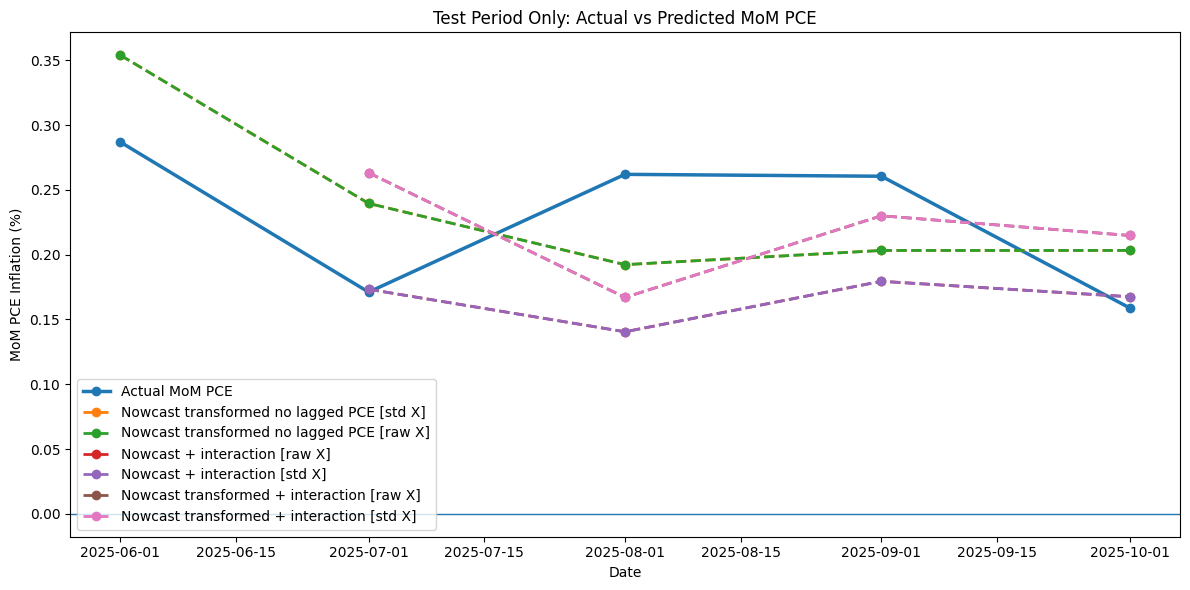

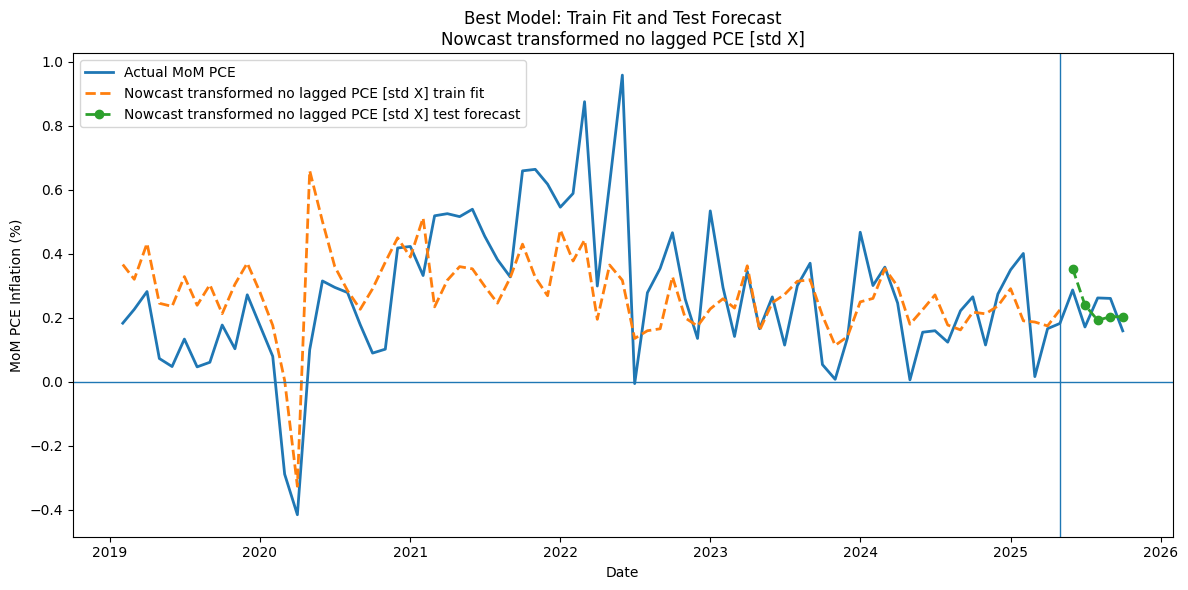


=== Nowcast transformed no lagged PCE [std X] | test predictions ===
        Date  Actual_MoM_PCE  Predicted_MoM_PCE     Error
0 2025-06-01        0.286817           0.353839 -0.067022
1 2025-07-01        0.171066           0.239518 -0.068452
2 2025-08-01        0.261944           0.192246  0.069698
3 2025-09-01        0.260476           0.203207  0.057269
4 2025-10-01        0.158933           0.203221 -0.044288

=== Nowcast transformed no lagged PCE [raw X] | test predictions ===
        Date  Actual_MoM_PCE  Predicted_MoM_PCE     Error
0 2025-06-01        0.286817           0.353839 -0.067022
1 2025-07-01        0.171066           0.239518 -0.068452
2 2025-08-01        0.261944           0.192246  0.069698
3 2025-09-01        0.260476           0.203207  0.057269
4 2025-10-01        0.158933           0.203221 -0.044288

=== Nowcast + interaction [raw X] | test predictions ===
        Date  Actual_MoM_PCE  Predicted_MoM_PCE     Error
0 2025-07-01        0.171066           0.173259 

In [20]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -----------------------------
# SETTINGS
# -----------------------------
DATE_COL = "Period_dt"
PCE_LEVEL_COL = "PersonalConsumptionExpenditures"

TRAIN_N = 76
MAKE_PLOTS = True
PRINT_TEST_TABLES = True

# -----------------------------
# 1) PREP DATA
# -----------------------------
monthly = monthly.copy()
monthly.columns = monthly.columns.str.strip()
monthly[DATE_COL] = pd.to_datetime(monthly[DATE_COL], errors="coerce")
monthly = monthly.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)

# Force key columns numeric when present
for c in monthly.columns:
    if c != DATE_COL:
        monthly[c] = pd.to_numeric(monthly[c], errors="coerce")

# -----------------------------
# 2) BUILD TARGET: MoM PCE inflation
#    Keep target in real percentage units
# -----------------------------
# Recommended target: monthly log inflation in percent
if "pce_mom" not in monthly.columns:
    monthly["pce_mom"] = 100 * (
        np.log(monthly[PCE_LEVEL_COL]) - np.log(monthly[PCE_LEVEL_COL].shift(1))
    )

if "pce_mom_lag1" not in monthly.columns:
    monthly["pce_mom_lag1"] = monthly["pce_mom"].shift(1)

# -----------------------------
# 3) BUILD FSBI COMPOSITE
# -----------------------------
if "fsbi_comp" not in monthly.columns:
    SALES_MOM_COL = "Real Sales MOM % - SA"
    TXN_MOM_COL = "Transaction MOM % - SA"
    SALES_IDX_COL = "Real Sales Index - SA"
    TXN_IDX_COL = "Transactional Index - SA"

    use_mom_cols = (SALES_MOM_COL in monthly.columns) and (TXN_MOM_COL in monthly.columns)

    if use_mom_cols:
        monthly["fsbi_sales_signal"] = monthly[SALES_MOM_COL]
        monthly["fsbi_txn_signal"] = monthly[TXN_MOM_COL]
    else:
        monthly["fsbi_sales_signal"] = monthly[SALES_IDX_COL] - monthly[SALES_IDX_COL].shift(1)
        monthly["fsbi_txn_signal"] = monthly[TXN_IDX_COL] - monthly[TXN_IDX_COL].shift(1)

    # Full-sample standardized composite for raw model construction
    monthly["fsbi_comp"] = (
        (monthly["fsbi_sales_signal"] - monthly["fsbi_sales_signal"].mean()) / monthly["fsbi_sales_signal"].std(ddof=0)
        + (monthly["fsbi_txn_signal"] - monthly["fsbi_txn_signal"].mean()) / monthly["fsbi_txn_signal"].std(ddof=0)
    ) * 12.0

if "fsbi_comp_lag1" not in monthly.columns:
    monthly["fsbi_comp_lag1"] = monthly["fsbi_comp"].shift(1)

# -----------------------------
# 4) BUILD LAGS / TRANSFORMS
# -----------------------------
# Contemporaneous and lagged BAA / NatGas / Oil
for col in ["CreditSpreadBAA", "USNaturalGasCompositePrice", "CrudeOilPrices"]:
    if col in monthly.columns and f"{col}_lag1" not in monthly.columns:
        monthly[f"{col}_lag1"] = monthly[col].shift(1)

# Log-difference transforms for energy variables
if "USNaturalGasCompositePrice" in monthly.columns and "natgas_mom" not in monthly.columns:
    monthly["natgas_mom"] = 100 * (
        np.log(monthly["USNaturalGasCompositePrice"]) -
        np.log(monthly["USNaturalGasCompositePrice"].shift(1))
    )

if "CrudeOilPrices" in monthly.columns and "oil_mom" not in monthly.columns:
    monthly["oil_mom"] = 100 * (
        np.log(monthly["CrudeOilPrices"]) -
        np.log(monthly["CrudeOilPrices"].shift(1))
    )

# Interaction term
if "fsbi_natgas_interaction" not in monthly.columns and \
   "fsbi_comp" in monthly.columns and "USNaturalGasCompositePrice" in monthly.columns:
    monthly["fsbi_natgas_interaction"] = monthly["fsbi_comp"] * monthly["USNaturalGasCompositePrice"]

if "fsbi_natgas_mom_interaction" not in monthly.columns and \
   "fsbi_comp" in monthly.columns and "natgas_mom" in monthly.columns:
    monthly["fsbi_natgas_mom_interaction"] = monthly["fsbi_comp"] * monthly["natgas_mom"]

# -----------------------------
# 5) MODEL SPECS
# -----------------------------
MODEL_SPECS = {
    "Nowcast base": ["fsbi_comp", "CreditSpreadBAA", "USNaturalGasCompositePrice", "pce_mom_lag1"],
    "Nowcast no lagged PCE": ["fsbi_comp", "CreditSpreadBAA", "USNaturalGasCompositePrice"],
    "Nowcast + oil": ["fsbi_comp", "CreditSpreadBAA", "USNaturalGasCompositePrice", "CrudeOilPrices", "pce_mom_lag1"],
    "Nowcast + interaction": ["fsbi_comp", "CreditSpreadBAA", "USNaturalGasCompositePrice", "fsbi_natgas_interaction", "pce_mom_lag1"],
    "Nowcast transformed energy": ["fsbi_comp", "CreditSpreadBAA", "natgas_mom", "oil_mom", "pce_mom_lag1"],
    "Nowcast transformed no lagged PCE": ["fsbi_comp", "CreditSpreadBAA", "natgas_mom", "oil_mom"],
    "Nowcast transformed + interaction": ["fsbi_comp", "CreditSpreadBAA", "natgas_mom", "oil_mom", "fsbi_natgas_mom_interaction", "pce_mom_lag1"],
}

# Filter model specs to columns that actually exist
MODEL_SPECS = {
    name: feats for name, feats in MODEL_SPECS.items()
    if all(f in monthly.columns for f in feats)
}

# -----------------------------
# 6) HELPERS
# -----------------------------
def zscore_train_test(train_df, test_df, feature_cols):
    """
    Standardize predictors using train-sample mean/std only.
    Returns transformed train/test DataFrames with same columns.
    """
    train_z = train_df.copy()
    test_z = test_df.copy()

    for c in feature_cols:
        mu = train_df[c].mean()
        sd = train_df[c].std(ddof=0)

        if pd.isna(sd) or sd == 0:
            train_z[c] = train_df[c] - mu
            test_z[c] = test_df[c] - mu
        else:
            train_z[c] = (train_df[c] - mu) / sd
            test_z[c] = (test_df[c] - mu) / sd

    return train_z, test_z


def evaluate_time_split(df, feature_cols, train_n=76, standardize_predictors=False):
    """
    Chronological train/test split:
    - train = first train_n rows
    - test = rest
    - recursive one-step-ahead forecasts on test

    standardize_predictors:
    - if True, standardizes X using each recursive train window only
    """
    use_cols = [DATE_COL, "pce_mom"] + feature_cols
    d = df[use_cols].dropna().reset_index(drop=True)

    if len(d) <= train_n:
        return None

    train = d.iloc[:train_n].copy()
    test = d.iloc[train_n:].copy()

    # Train fit
    if standardize_predictors:
        train_fit_X, _ = zscore_train_test(train[feature_cols], train[feature_cols], feature_cols)
        X_train = sm.add_constant(train_fit_X[feature_cols], has_constant="add")
    else:
        X_train = sm.add_constant(train[feature_cols], has_constant="add")

    y_train = train["pce_mom"]
    train_model = sm.OLS(y_train, X_train).fit()
    train_fitted = train_model.predict(X_train)

    # Recursive test forecasts
    preds = []
    for i in range(len(test)):
        target_date = test.iloc[i][DATE_COL]

        current_train = d[d[DATE_COL] < target_date].copy()
        current_test = d[d[DATE_COL] == target_date].copy()

        if standardize_predictors:
            Xtr_raw = current_train[feature_cols].copy()
            Xte_raw = current_test[feature_cols].copy()
            Xtr_z, Xte_z = zscore_train_test(Xtr_raw, Xte_raw, feature_cols)
            X_tr = sm.add_constant(Xtr_z[feature_cols], has_constant="add")
            X_te = sm.add_constant(Xte_z[feature_cols], has_constant="add")
        else:
            X_tr = sm.add_constant(current_train[feature_cols], has_constant="add")
            X_te = sm.add_constant(current_test[feature_cols], has_constant="add")

        y_tr = current_train["pce_mom"]
        X_te = X_te[X_tr.columns]

        model = sm.OLS(y_tr, X_tr).fit()
        pred = model.predict(X_te).item()
        actual = current_test["pce_mom"].iloc[0]

        preds.append({
            "Date": target_date,
            "Actual_MoM_PCE": actual,
            "Predicted_MoM_PCE": pred,
            "Error": actual - pred,
            "Abs_Error": abs(actual - pred),
            "Sq_Error": (actual - pred) ** 2,
        })

    test_results = pd.DataFrame(preds)
    test_mse = test_results["Sq_Error"].mean()
    test_rmse = np.sqrt(test_mse)
    test_mae = test_results["Abs_Error"].mean()
    test_da   = directional_accuracy(test_results["Actual_MoM_PCE"], test_results["Predicted_MoM_PCE"])
    test_mape = mape(test_results["Actual_MoM_PCE"], test_results["Predicted_MoM_PCE"])
    


    return {
        "data": d,
        "train": train,
        "test": test,
        "train_model": train_model,
        "train_fitted": train_fitted,
        "test_results": test_results,
        "test_mse": test_mse,
        "test_da": test_da,
        "test_mape": test_mape,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "n_train": len(train),
        "n_test": len(test),
    }


def run_model_grid(df, model_specs, train_n=76, standardize_predictors=False):
    all_results = {}
    rows = []

    for model_name, feats in model_specs.items():
        res = evaluate_time_split(df, feats, train_n=train_n, standardize_predictors=standardize_predictors)
        if res is None:
            continue

        tag = model_name + (" [std X]" if standardize_predictors else " [raw X]")
        all_results[tag] = res

        rows.append({
            "model": tag,
            "features": feats,
            "test_mse": res["test_mse"],
            "test_rmse": res["test_rmse"],
            "test_mae": res["test_mae"],
            "test_da_pct": res["test_da"],
            "test_mape_pct": res["test_mape"],
            "n_train": res["n_train"],
            "n_test": res["n_test"],
        })

    summary_df = pd.DataFrame(rows).sort_values("test_mse").reset_index(drop=True)
    return all_results, summary_df


def fit_latest_nowcast(df, feature_cols, standardize_predictors=False):
    """
    Fit model on all available rows and produce nowcast for latest available month
    in the filtered sample.
    """
    use_cols = [DATE_COL, "pce_mom"] + feature_cols
    d = df[use_cols].dropna().reset_index(drop=True)

    if standardize_predictors:
        X_raw = d[feature_cols].copy()
        X_z, _ = zscore_train_test(X_raw, X_raw, feature_cols)
        X = sm.add_constant(X_z[feature_cols], has_constant="add")
    else:
        X = sm.add_constant(d[feature_cols], has_constant="add")

    y = d["pce_mom"]
    model = sm.OLS(y, X).fit()

    latest_date = d[DATE_COL].iloc[-1]
    latest_row = d.iloc[-1:][feature_cols].copy()

    if standardize_predictors:
        X_tr_raw = d[feature_cols].copy()
        _, latest_z = zscore_train_test(X_tr_raw, latest_row.copy(), feature_cols)
        X_now = sm.add_constant(latest_z[feature_cols], has_constant="add")
    else:
        X_now = sm.add_constant(latest_row[feature_cols], has_constant="add")

    X_now = X_now[X.columns]
    nowcast = model.predict(X_now).item()

    return model, latest_date, nowcast

# -----------------------------
# 7) RUN RAW-X MODEL GRID
# -----------------------------
raw_results, raw_summary = run_model_grid(
    monthly, MODEL_SPECS, train_n=TRAIN_N, standardize_predictors=False
)

print("=== MODEL COMPARISON: RAW PREDICTORS ===")
print(raw_summary)

# -----------------------------
# 8) RUN STANDARDIZED-X MODEL GRID
# -----------------------------
std_results, std_summary = run_model_grid(
    monthly, MODEL_SPECS, train_n=TRAIN_N, standardize_predictors=True
)

print("\n=== MODEL COMPARISON: STANDARDIZED PREDICTORS ===")
print(std_summary)

# -----------------------------
# 9) COMBINED RANKING
# -----------------------------
combined_summary = pd.concat([raw_summary, std_summary], axis=0, ignore_index=True)
combined_summary = combined_summary.sort_values("test_mse").reset_index(drop=True)

print("\n=== OVERALL MODEL RANKING ===")
print(combined_summary)

best_model_name = combined_summary.loc[0, "model"]
best_features = combined_summary.loc[0, "features"]

print("\nBest overall model:", best_model_name)
print("Best feature set:", best_features)

# pick correct result store
best_result = raw_results.get(best_model_name, None)
if best_result is None:
    best_result = std_results.get(best_model_name, None)

# -----------------------------
# 10) PLOTS
# -----------------------------
if MAKE_PLOTS and len(combined_summary) > 0:
    # Test-period plot for top models
    plt.figure(figsize=(12, 6))

    ref = best_result["test_results"]
    plt.plot(
        ref["Date"], ref["Actual_MoM_PCE"],
        marker="o", linewidth=2.5, label="Actual MoM PCE"
    )

    for model_name in combined_summary["model"].head(6):
        res = raw_results.get(model_name, None)
        if res is None:
            res = std_results.get(model_name, None)
        tr = res["test_results"]

        plt.plot(
            tr["Date"], tr["Predicted_MoM_PCE"],
            marker="o", linestyle="--", linewidth=2, label=model_name
        )

    plt.axhline(0, linewidth=1)
    plt.title("Test Period Only: Actual vs Predicted MoM PCE")
    plt.xlabel("Date")
    plt.ylabel("MoM PCE Inflation (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Best model train fit + test forecast
    plt.figure(figsize=(12, 6))

    plt.plot(
        best_result["data"][DATE_COL], best_result["data"]["pce_mom"],
        linewidth=2, label="Actual MoM PCE"
    )

    plt.plot(
        best_result["train"][DATE_COL], best_result["train_fitted"],
        linestyle="--", linewidth=2, label=f"{best_model_name} train fit"
    )

    plt.plot(
        best_result["test_results"]["Date"], best_result["test_results"]["Predicted_MoM_PCE"],
        linestyle="--", linewidth=2, marker="o", label=f"{best_model_name} test forecast"
    )

    plt.axvline(best_result["train"][DATE_COL].iloc[-1], linewidth=1)
    plt.axhline(0, linewidth=1)
    plt.title(f"Best Model: Train Fit and Test Forecast\n{best_model_name}")
    plt.xlabel("Date")
    plt.ylabel("MoM PCE Inflation (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# -----------------------------
# 11) OPTIONAL: PRINT TEST TABLES
# -----------------------------
if PRINT_TEST_TABLES and len(combined_summary) > 0:
    for model_name in combined_summary["model"].head(5):
        res = raw_results.get(model_name, None)
        if res is None:
            res = std_results.get(model_name, None)

        print(f"\n=== {model_name} | test predictions ===")
        print(res["test_results"][["Date", "Actual_MoM_PCE", "Predicted_MoM_PCE", "Error"]])

# -----------------------------
# 12) FIT BEST MODEL ON ALL AVAILABLE DATA AND PRODUCE LATEST NOWCAST
# -----------------------------
best_is_std = "[std X]" in best_model_name
base_name = best_model_name.replace(" [std X]", "").replace(" [raw X]", "")

best_model, latest_date, latest_nowcast = fit_latest_nowcast(
    monthly,
    MODEL_SPECS[base_name],
    standardize_predictors=best_is_std
)

print("\n=== LATEST NOWCAST FROM BEST MODEL ===")
print("Model:", best_model_name)
print("Forecast month:", pd.to_datetime(latest_date).date())
print("Predicted MoM PCE (%):", round(latest_nowcast, 4))

print("\n=== BEST MODEL SUMMARY ===")
print(best_model.summary())



=== NOWCAST NONLINEAR MODEL COMPARISON ===
                             model  \
0  Nowcast + interaction + squares   
1                   Linear nowcast   
2            Nowcast + interaction   

                                            features  test_mse  test_rmse  \
0  [fsbi_comp, CreditSpreadBAA, natgas_mom, oil_m...  0.003689   0.060734   
1  [fsbi_comp, CreditSpreadBAA, natgas_mom, oil_mom]  0.003855   0.062091   
2  [fsbi_comp, CreditSpreadBAA, natgas_mom, oil_m...  0.004220   0.064962   

   test_mae  n_train  n_test  
0  0.059854       76       5  
1  0.061346       76       5  
2  0.064308       76       5  


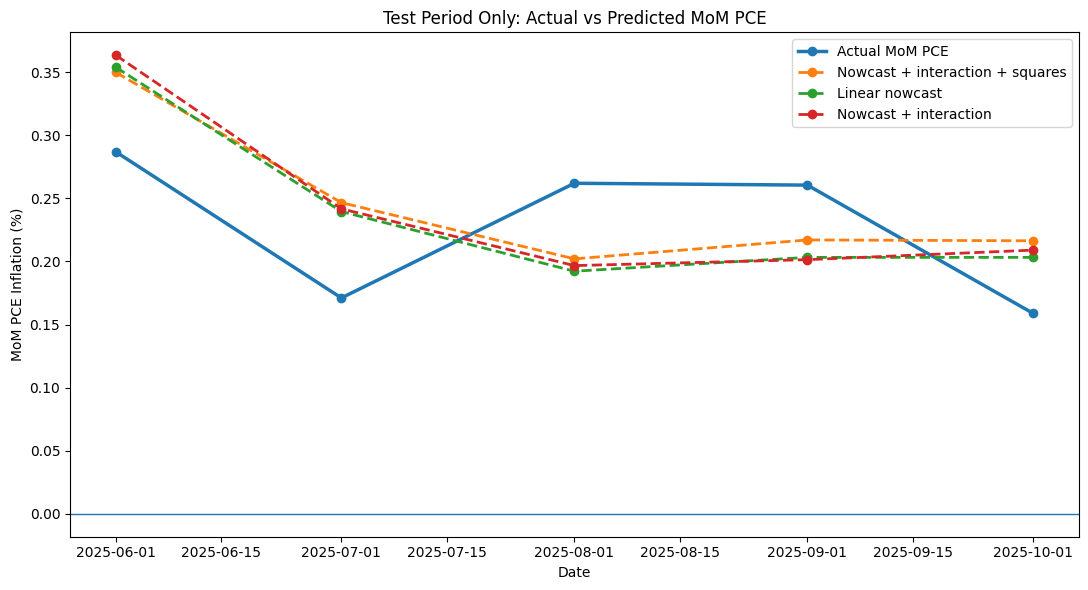

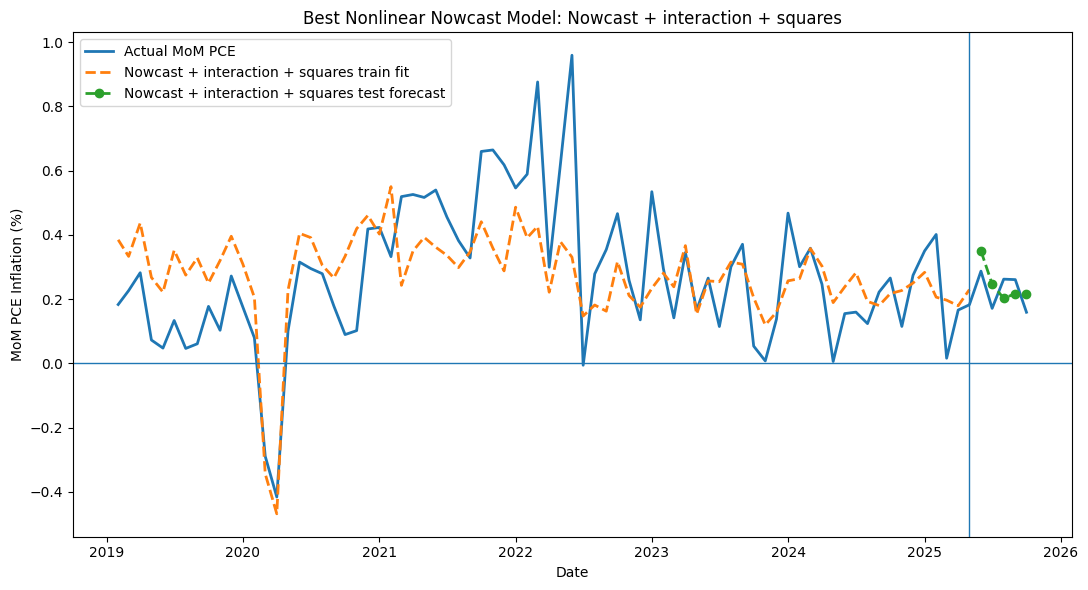


=== Nowcast + interaction + squares | test predictions ===
        Date  Actual_MoM_PCE  Predicted_MoM_PCE     Error
0 2025-06-01        0.286817           0.349766 -0.062949
1 2025-07-01        0.171066           0.246611 -0.075545
2 2025-08-01        0.261944           0.202039  0.059905
3 2025-09-01        0.260476           0.217031  0.043445
4 2025-10-01        0.158933           0.216359 -0.057426

=== Linear nowcast | test predictions ===
        Date  Actual_MoM_PCE  Predicted_MoM_PCE     Error
0 2025-06-01        0.286817           0.353839 -0.067022
1 2025-07-01        0.171066           0.239518 -0.068452
2 2025-08-01        0.261944           0.192246  0.069698
3 2025-09-01        0.260476           0.203207  0.057269
4 2025-10-01        0.158933           0.203221 -0.044288

=== Nowcast + interaction | test predictions ===
        Date  Actual_MoM_PCE  Predicted_MoM_PCE     Error
0 2025-06-01        0.286817           0.363386 -0.076569
1 2025-07-01        0.171066       

In [62]:
# ============================================================
# TEST 3 NOWCAST MODELS FOR MoM PCE
# ------------------------------------------------------------
# 1) Current best linear nowcast:
#    fsbi_comp + CreditSpreadBAA + natgas_mom + oil_mom
#
# 2) Add interaction:
#    + fsbi_comp * natgas_mom
#
# 3) Add interaction + nonlinear energy terms:
#    + fsbi_comp * natgas_mom + natgas_mom^2 + oil_mom^2
#
# Uses:
# - 76 / rest chronological split
# - recursive one-step-ahead forecasts in test period
# - plots test-period actual vs predicted
# - plots best model train fit + test forecast
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

DATE_COL = "Period_dt"
PCE_LEVEL_COL = "PersonalConsumptionExpenditures"
TRAIN_N = 76

monthly = monthly.copy().sort_values(DATE_COL).reset_index(drop=True)

# ------------------------------------------------------------
# 1) Build target and transformed variables if missing
# ------------------------------------------------------------
if "pce_mom" not in monthly.columns:
    monthly["pce_mom"] = 100 * (
        np.log(monthly[PCE_LEVEL_COL]) - np.log(monthly[PCE_LEVEL_COL].shift(1))
    )

if "fsbi_comp" not in monthly.columns:
    SALES_MOM_COL = "Real Sales MOM % - SA"
    TXN_MOM_COL = "Transaction MOM % - SA"
    SALES_IDX_COL = "Real Sales Index - SA"
    TXN_IDX_COL = "Transactional Index - SA"

    use_mom_cols = (SALES_MOM_COL in monthly.columns) and (TXN_MOM_COL in monthly.columns)

    if use_mom_cols:
        monthly["fsbi_sales_signal"] = monthly[SALES_MOM_COL]
        monthly["fsbi_txn_signal"] = monthly[TXN_MOM_COL]
    else:
        monthly["fsbi_sales_signal"] = monthly[SALES_IDX_COL] - monthly[SALES_IDX_COL].shift(1)
        monthly["fsbi_txn_signal"] = monthly[TXN_IDX_COL] - monthly[TXN_IDX_COL].shift(1)

    monthly["fsbi_comp"] = (
        (monthly["fsbi_sales_signal"] - monthly["fsbi_sales_signal"].mean()) / monthly["fsbi_sales_signal"].std(ddof=0)
        + (monthly["fsbi_txn_signal"] - monthly["fsbi_txn_signal"].mean()) / monthly["fsbi_txn_signal"].std(ddof=0)
    ) * 12.0

if "natgas_mom" not in monthly.columns:
    monthly["natgas_mom"] = 100 * (
        np.log(monthly["USNaturalGasCompositePrice"]) -
        np.log(monthly["USNaturalGasCompositePrice"].shift(1))
    )

if "oil_mom" not in monthly.columns:
    monthly["oil_mom"] = 100 * (
        np.log(monthly["CrudeOilPrices"]) -
        np.log(monthly["CrudeOilPrices"].shift(1))
    )

# Interaction + squares
monthly["fsbi_natgas_mom_interaction"] = monthly["fsbi_comp"] * monthly["natgas_mom"]
monthly["natgas_mom_sq"] = monthly["natgas_mom"] ** 2
monthly["oil_mom_sq"] = monthly["oil_mom"] ** 2

# ------------------------------------------------------------
# 2) Define model specs
# ------------------------------------------------------------
MODEL_SPECS = {
    "Linear nowcast": [
        "fsbi_comp",
        "CreditSpreadBAA",
        "natgas_mom",
        "oil_mom",
    ],
    "Nowcast + interaction": [
        "fsbi_comp",
        "CreditSpreadBAA",
        "natgas_mom",
        "oil_mom",
        "fsbi_natgas_mom_interaction",
    ],
    "Nowcast + interaction + squares": [
        "fsbi_comp",
        "CreditSpreadBAA",
        "natgas_mom",
        "oil_mom",
        "fsbi_natgas_mom_interaction",
        "natgas_mom_sq",
        "oil_mom_sq",
    ],
}

# Keep only models whose cols exist
MODEL_SPECS = {
    name: feats for name, feats in MODEL_SPECS.items()
    if all(f in monthly.columns for f in feats)
}

# ------------------------------------------------------------
# 3) Helper
# ------------------------------------------------------------
def evaluate_time_split(df, feature_cols, train_n=76):
    use_cols = [DATE_COL, "pce_mom"] + feature_cols
    d = df[use_cols].dropna().reset_index(drop=True)

    if len(d) <= train_n:
        return None

    train = d.iloc[:train_n].copy()
    test = d.iloc[train_n:].copy()

    # Train fit
    X_train = sm.add_constant(train[feature_cols], has_constant="add")
    y_train = train["pce_mom"]
    train_model = sm.OLS(y_train, X_train).fit()
    train_fitted = train_model.predict(X_train)

    # Recursive test forecasts
    preds = []
    for i in range(len(test)):
        target_date = test.iloc[i][DATE_COL]

        current_train = d[d[DATE_COL] < target_date].copy()
        current_test = d[d[DATE_COL] == target_date].copy()

        X_tr = sm.add_constant(current_train[feature_cols], has_constant="add")
        y_tr = current_train["pce_mom"]

        X_te = sm.add_constant(current_test[feature_cols], has_constant="add")
        X_te = X_te[X_tr.columns]

        model = sm.OLS(y_tr, X_tr).fit()
        pred = model.predict(X_te).item()
        actual = current_test["pce_mom"].iloc[0]

        preds.append({
            "Date": target_date,
            "Actual_MoM_PCE": actual,
            "Predicted_MoM_PCE": pred,
            "Error": actual - pred,
            "Abs_Error": abs(actual - pred),
            "Sq_Error": (actual - pred) ** 2,
        })

    test_results = pd.DataFrame(preds)
    test_mse = test_results["Sq_Error"].mean()
    test_rmse = np.sqrt(test_mse)
    test_mae = test_results["Abs_Error"].mean()

    return {
        "data": d,
        "train": train,
        "test": test,
        "train_model": train_model,
        "train_fitted": train_fitted,
        "test_results": test_results,
        "test_mse": test_mse,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "n_train": len(train),
        "n_test": len(test),
    }

# ------------------------------------------------------------
# 4) Run models
# ------------------------------------------------------------
all_results = {}
rows = []

for model_name, feats in MODEL_SPECS.items():
    res = evaluate_time_split(monthly, feats, train_n=TRAIN_N)
    if res is None:
        continue
    all_results[model_name] = res
    rows.append({
        "model": model_name,
        "features": feats,
        "test_mse": res["test_mse"],
        "test_rmse": res["test_rmse"],
        "test_mae": res["test_mae"],
        "n_train": res["n_train"],
        "n_test": res["n_test"],
    })

summary_df = pd.DataFrame(rows).sort_values("test_mse").reset_index(drop=True)

print("=== NOWCAST NONLINEAR MODEL COMPARISON ===")
print(summary_df)

# ------------------------------------------------------------
# 5) Plot test-period actual vs predicted for all three models
# ------------------------------------------------------------
best_model_name = summary_df.loc[0, "model"]
ref = all_results[best_model_name]["test_results"]

plt.figure(figsize=(11, 6))
plt.plot(
    ref["Date"], ref["Actual_MoM_PCE"],
    marker="o", linewidth=2.5, label="Actual MoM PCE"
)

for model_name in summary_df["model"]:
    tr = all_results[model_name]["test_results"]
    plt.plot(
        tr["Date"], tr["Predicted_MoM_PCE"],
        marker="o", linestyle="--", linewidth=2, label=model_name
    )

plt.axhline(0, linewidth=1)
plt.title("Test Period Only: Actual vs Predicted MoM PCE")
plt.xlabel("Date")
plt.ylabel("MoM PCE Inflation (%)")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) Plot best model train fit + test forecast
# ------------------------------------------------------------
best_res = all_results[best_model_name]

plt.figure(figsize=(11, 6))
plt.plot(
    best_res["data"][DATE_COL], best_res["data"]["pce_mom"],
    linewidth=2, label="Actual MoM PCE"
)
plt.plot(
    best_res["train"][DATE_COL], best_res["train_fitted"],
    linestyle="--", linewidth=2, label=f"{best_model_name} train fit"
)
plt.plot(
    best_res["test_results"]["Date"], best_res["test_results"]["Predicted_MoM_PCE"],
    linestyle="--", linewidth=2, marker="o", label=f"{best_model_name} test forecast"
)

plt.axvline(best_res["train"][DATE_COL].iloc[-1], linewidth=1)
plt.axhline(0, linewidth=1)
plt.title(f"Best Nonlinear Nowcast Model: {best_model_name}")
plt.xlabel("Date")
plt.ylabel("MoM PCE Inflation (%)")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7) Print test predictions for each model
# ------------------------------------------------------------
for model_name in summary_df["model"]:
    print(f"\n=== {model_name} | test predictions ===")
    print(all_results[model_name]["test_results"][["Date", "Actual_MoM_PCE", "Predicted_MoM_PCE", "Error"]])

# ------------------------------------------------------------
# 8) Fit best model on all available data and give latest nowcast
# ------------------------------------------------------------
best_features = MODEL_SPECS[best_model_name]
final_df = monthly[[DATE_COL, "pce_mom"] + best_features].dropna().reset_index(drop=True)

X_final = sm.add_constant(final_df[best_features], has_constant="add")
y_final = final_df["pce_mom"]

final_model = sm.OLS(y_final, X_final).fit()

latest_row = final_df.iloc[-1]
X_now = pd.DataFrame([{"const": 1.0, **{c: latest_row[c] for c in best_features}}])
X_now = X_now[final_model.model.exog_names]

latest_nowcast = final_model.predict(X_now).item()

print("\n=== LATEST NOWCAST FROM BEST NONLINEAR MODEL ===")
print("Best model:", best_model_name)
print("Forecast month:", pd.to_datetime(latest_row[DATE_COL]).date())
print("Predicted MoM PCE (%):", round(latest_nowcast, 4))

print("\n=== BEST NONLINEAR MODEL SUMMARY ===")
print(final_model.summary())